<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Segmentaci%C3%B3n_de_Cromosomas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliabedimadiseh/chromosome-image-dataset-karyotype")

print("Path to dataset files:", path)

100%|██████████| 990M/990M [00:52<00:00, 19.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aliabedimadiseh/chromosome-image-dataset-karyotype/versions/4


In [2]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-r0v4yl_2
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-r0v4yl_2
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36634 sha256=ed473afd7774ea1355ab40b96edcc03d0cd0baba8e6f48be0c7652428ca716e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-5dn_3far/wheels/5d/7b/4a/c7fda89f2e27647dd0816f51ea103992b1b6f0f53ad234895c
Successfully built segment_anything


In [ ]:
import os
import cv2
import sys
import random
from segment_anything import sam_model_registry
from segment_anything import SamAutomaticMaskGenerator
from segment_anything import SamPredictor
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import matplotlib.patches as patches

In [ ]:
def show_anns(anns, axes=None):
    if len(anns) == 0:
        return
    if axes:
        ax = axes
    else:
        ax = plt.gca()
        ax.set_autoscale_on(False)
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    polygons = []
    color = []
    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0],m.shape[1],3))
        color_mask = np.random.random((1,3)).tolist()[0]
        for i in range(3):
            img[:,:,i] = color_mask[i]
        ax.imshow(np.dstack((img, m*0.8)))

In [ ]:
import os
import urllib.request

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda" # Cambia a "cuda" si tienes la GPU activada

# Descargar el checkpoint oficial si no existe localmente
if not os.path.exists(sam_checkpoint):
    print("Descargando el modelo SAM (vit_h)... Esto puede tardar unos minutos.")
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
    urllib.request.urlretrieve(url, sam_checkpoint)
    print("Descarga completada!")

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
mask_generator1 = SamAutomaticMaskGenerator(sam)

Descargando el modelo SAM (vit_h)... Esto puede tardar unos minutos.
Descarga completada!


In [ ]:
path0 = os.path.join(path, 'Data/24_chromosomes_object/JEPG/103064.jpg')

image = cv2.imread(path0)
if image is None:
    raise FileNotFoundError(f"No se pudo encontrar la imagen en la ruta: {path0}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

masks1 = mask_generator1.generate(image)

fig, axs = plt.subplots(1,3,figsize=(12,4))
axs[0].imshow(image)
axs[2].imshow(image)
show_anns(masks1,axs[1])
show_anns(masks1,axs[2])
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
plt.show()

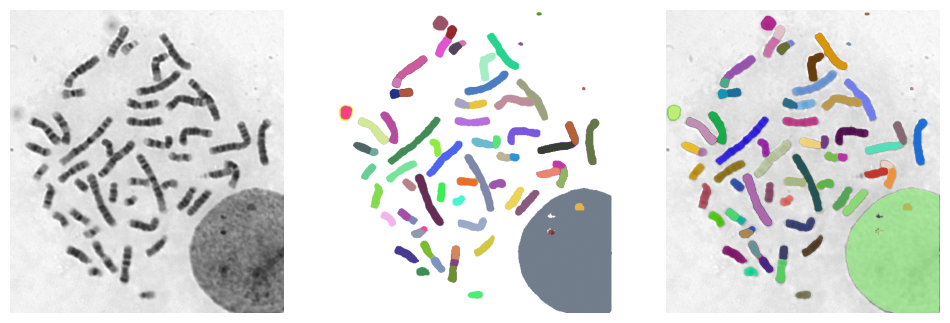

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(12,4))
axs[0].imshow(image)
axs[2].imshow(image)
show_anns(masks1,axs[1])
show_anns(masks1,axs[2])
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
plt.show()

In [ ]:
bgw=np.ones(image.shape)*255
print(len(masks1))
print(masks1[0].keys())

87
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


(581, 524, 3)


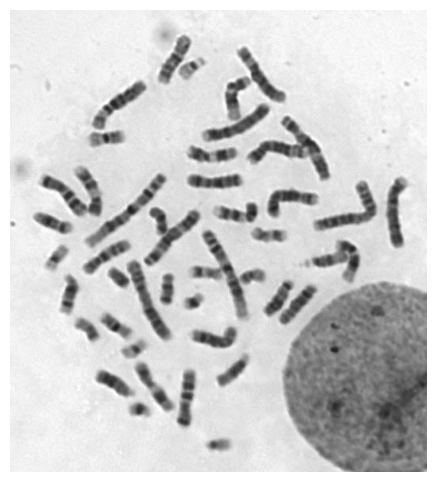

In [ ]:
print(image.shape)
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis('off')
plt.show()

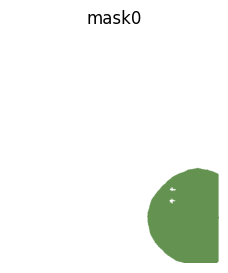

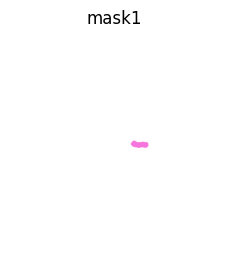

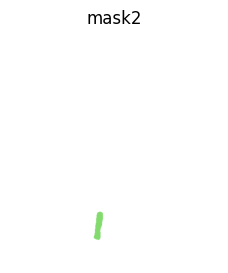

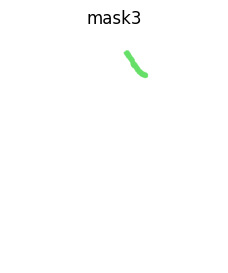

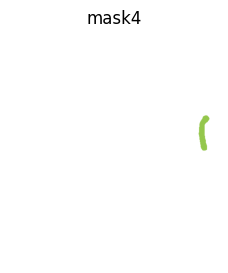

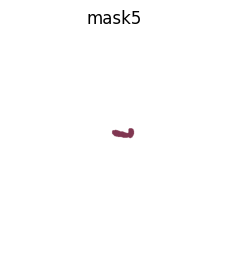

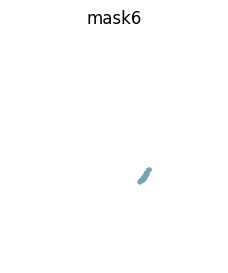

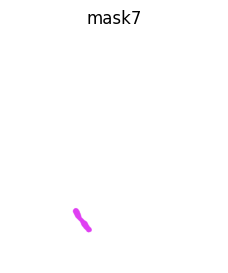

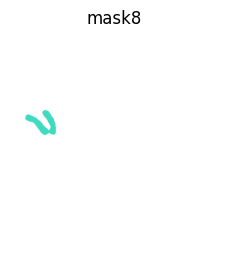

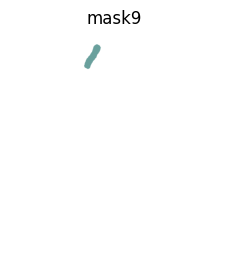

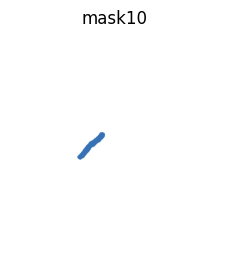

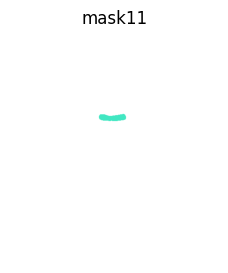

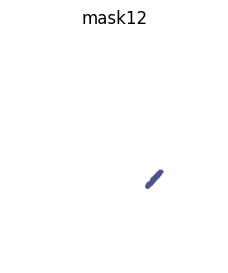

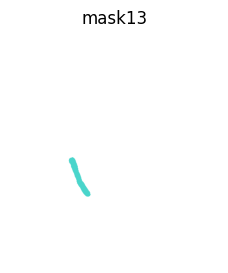

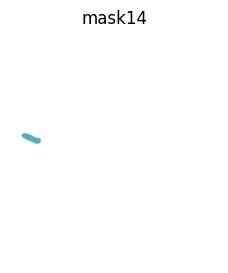

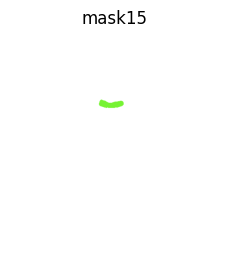

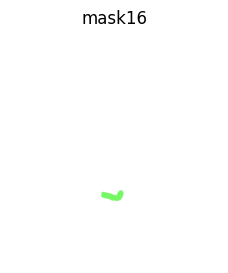

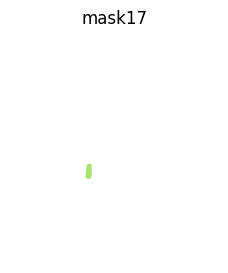

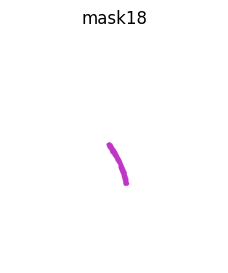

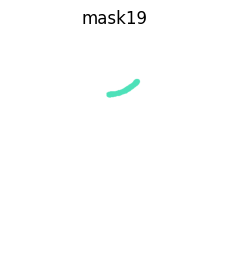

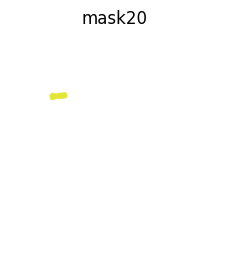

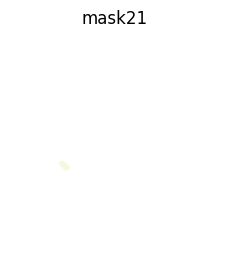

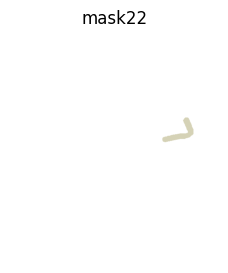

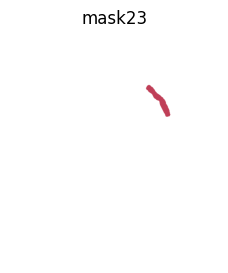

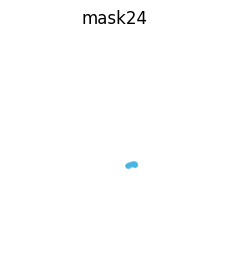

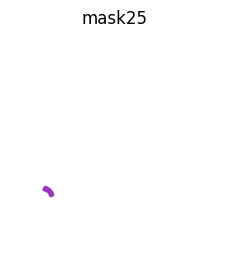

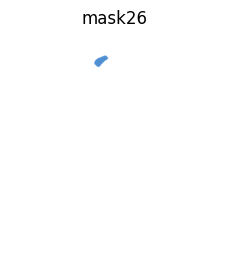

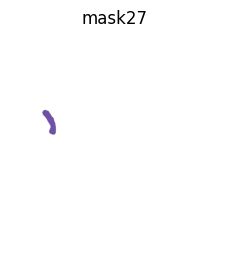

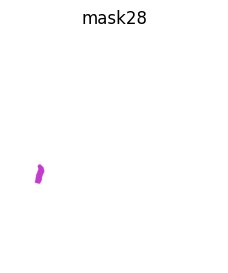

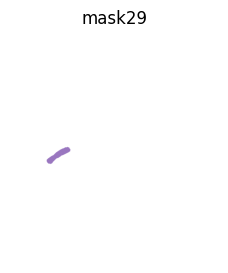

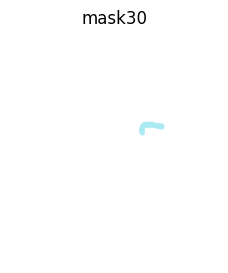

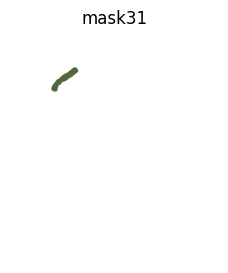

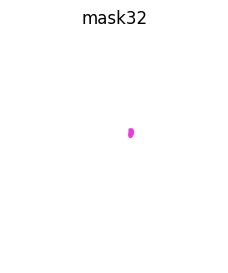

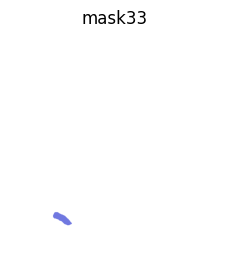

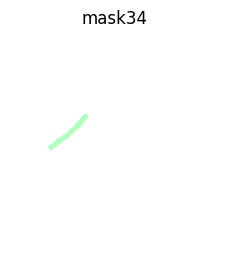

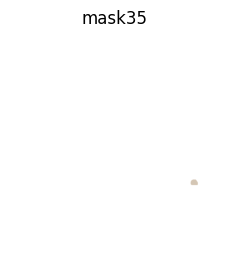

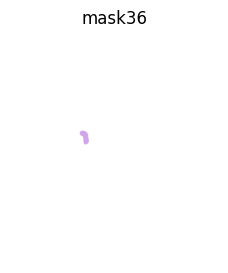

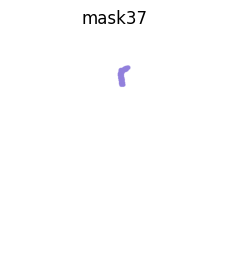

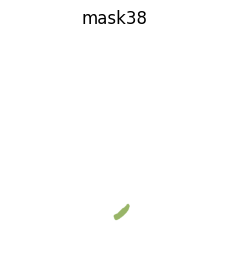

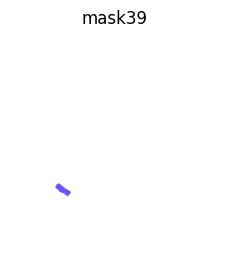

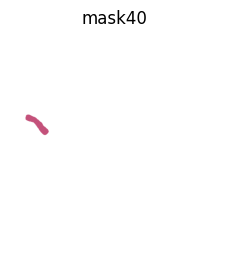

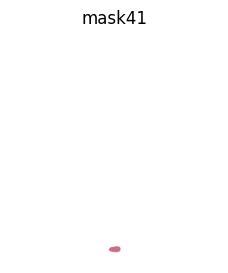

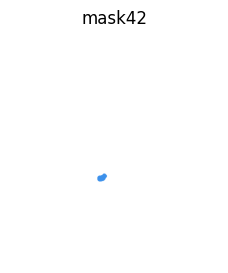

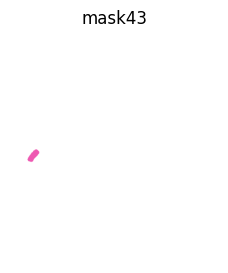

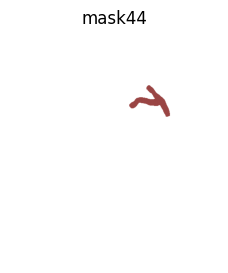

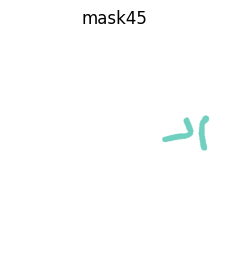

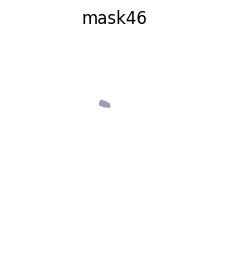

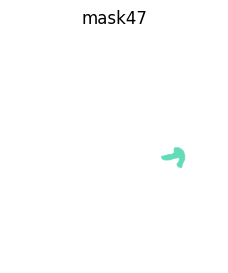

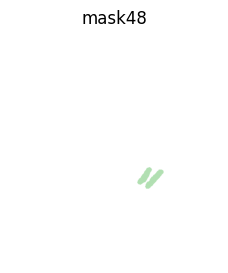

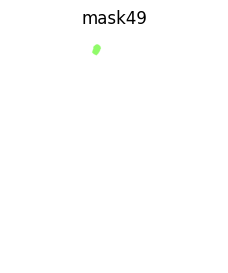

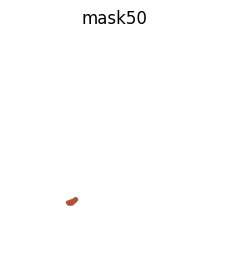

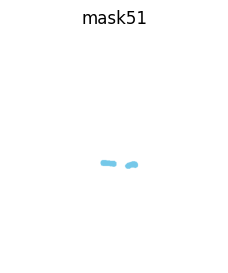

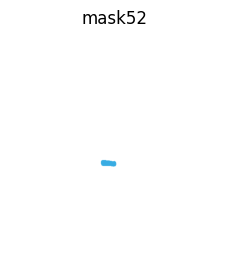

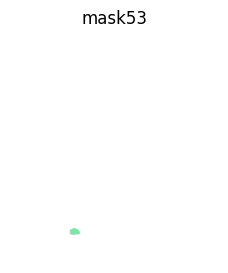

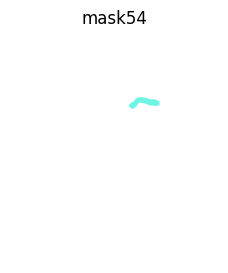

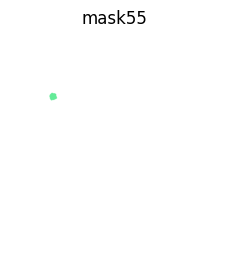

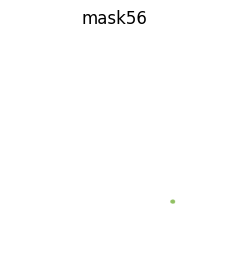

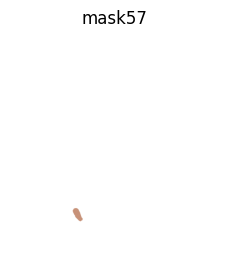

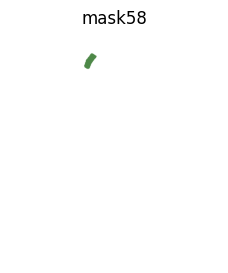

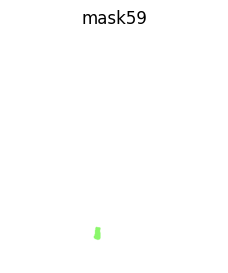

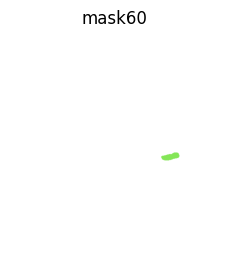

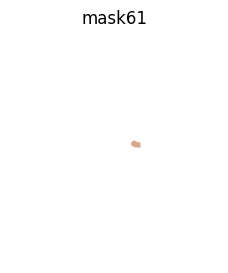

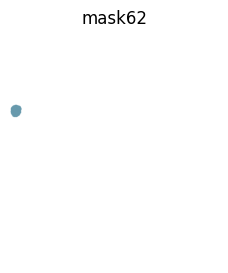

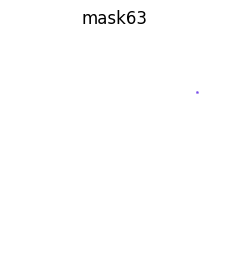

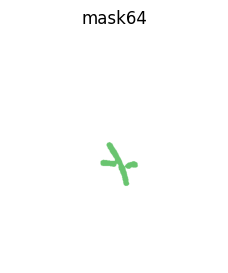

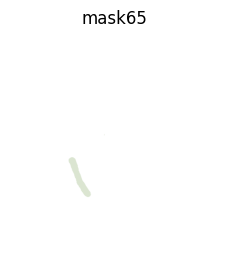

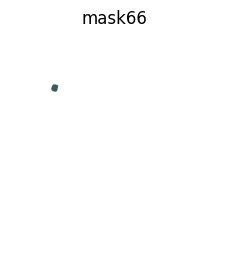

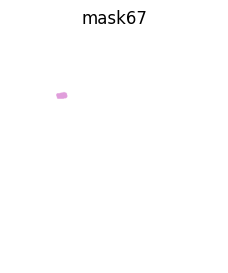

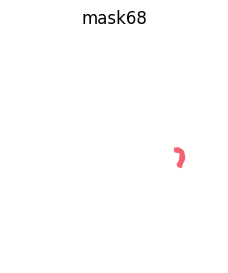

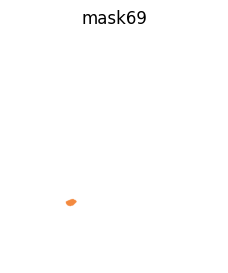

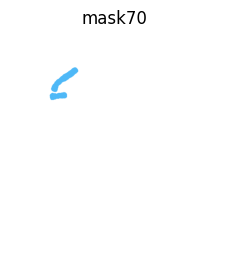

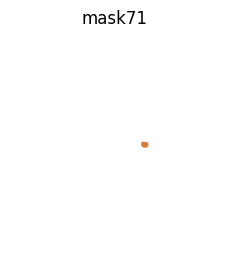

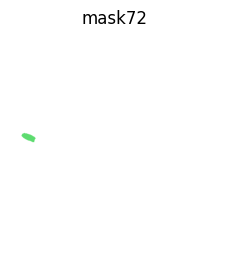

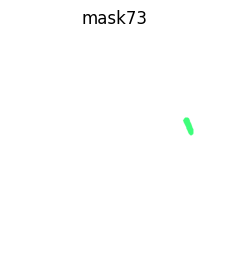

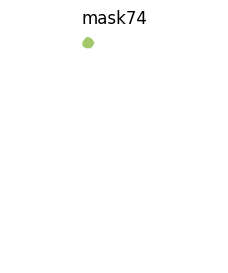

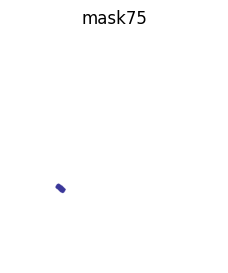

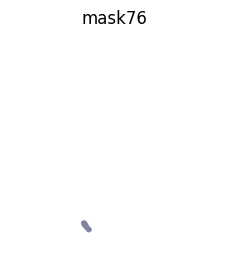

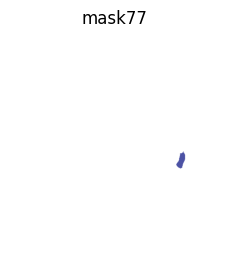

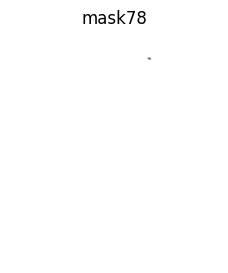

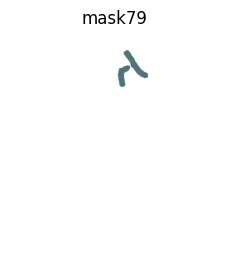

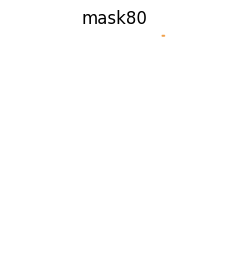

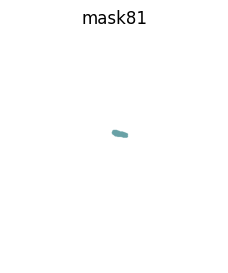

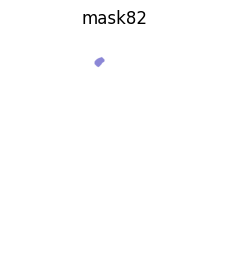

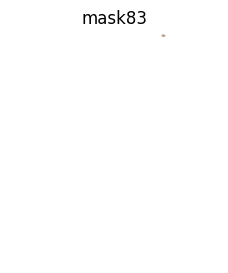

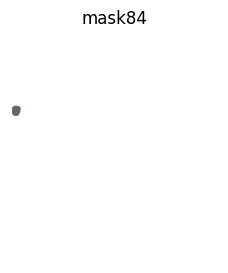

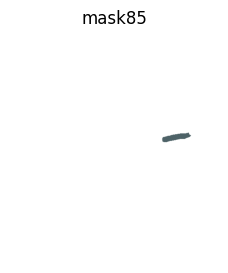

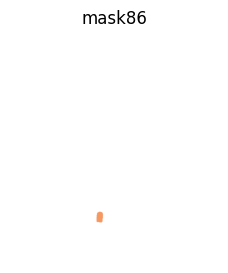

In [ ]:
#slices of mask image
for i in range(len(masks1)):
    plt.figure(figsize=(3,3))
    plt.imshow(bgw)
    show_anns([masks1[i]])
    plt.title(f'mask{i}')
    plt.axis('off')
    plt.show()

mask0
[344, 342, 179, 238]
[344, 523, 342, 580]


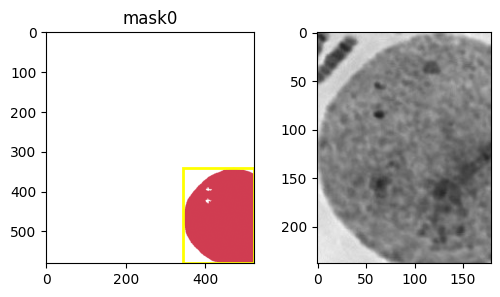

mask1
[303, 273, 43, 18]
[303, 346, 273, 291]


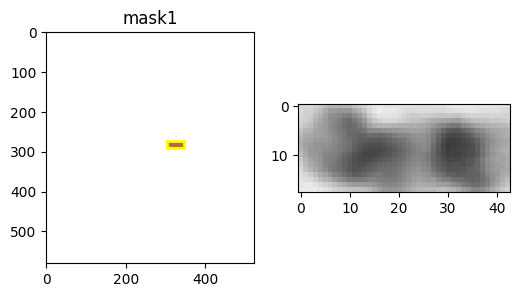

mask2
[210, 452, 22, 70]
[210, 232, 452, 522]


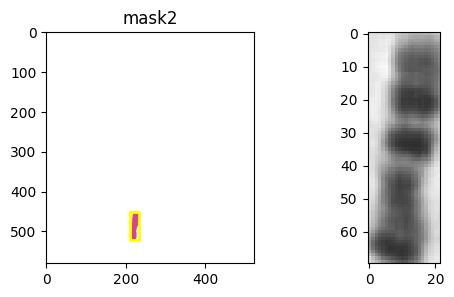

mask3
[285, 46, 60, 69]
[285, 345, 46, 115]


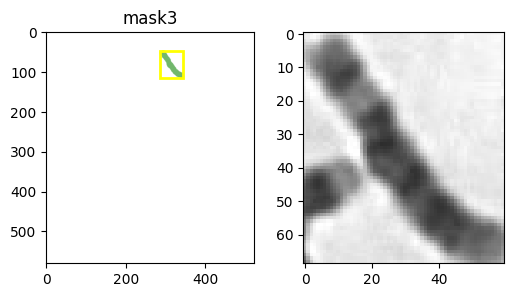

mask4
[473, 209, 26, 89]
[473, 499, 209, 298]


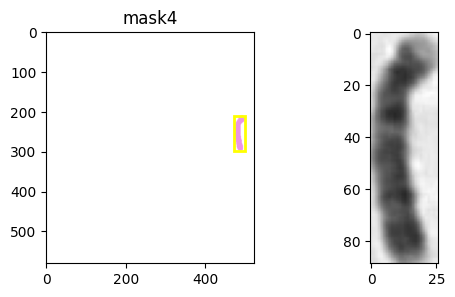

mask5
[256, 242, 54, 24]
[256, 310, 242, 266]


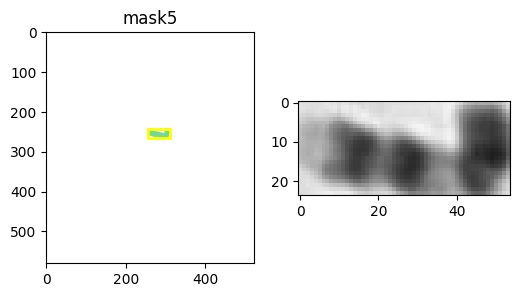

mask6
[319, 340, 36, 43]
[319, 355, 340, 383]


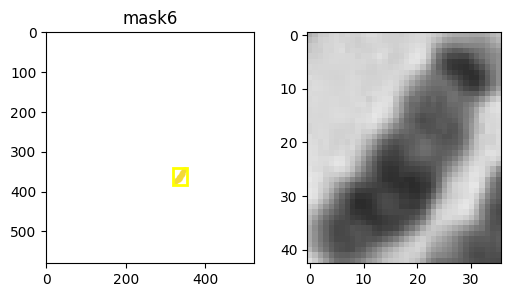

mask7
[157, 443, 47, 60]
[157, 204, 443, 503]


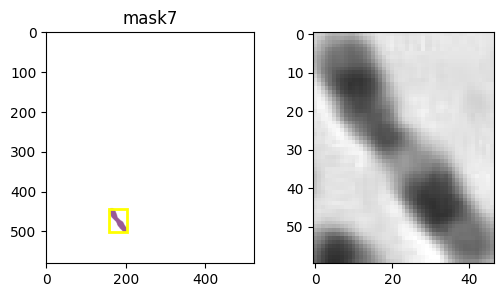

mask8
[38, 196, 76, 62]
[38, 114, 196, 258]


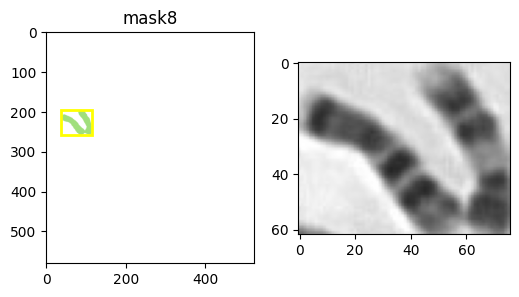

mask9
[186, 31, 41, 61]
[186, 227, 31, 92]


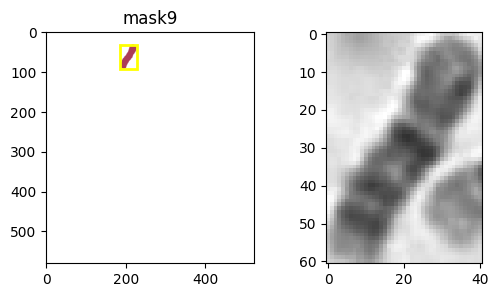

mask10
[169, 252, 68, 68]
[169, 237, 252, 320]


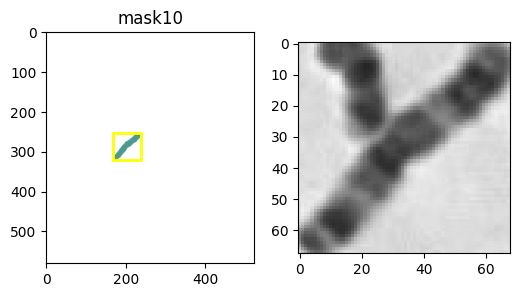

mask11
[223, 206, 67, 17]
[223, 290, 206, 223]


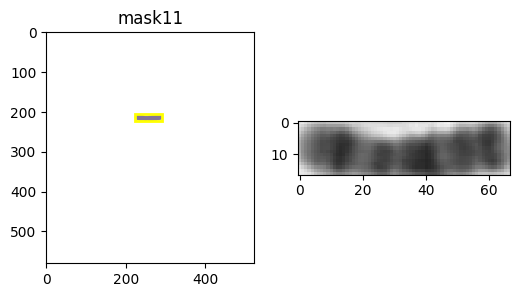

mask12
[339, 346, 45, 48]
[339, 384, 346, 394]


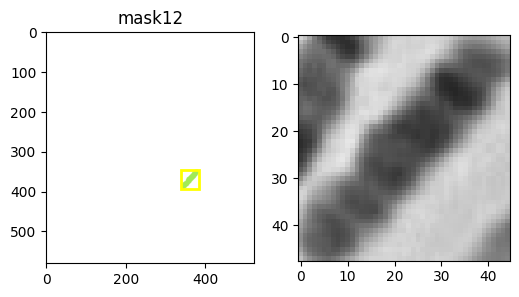

mask13
[147, 315, 54, 98]
[147, 201, 315, 413]


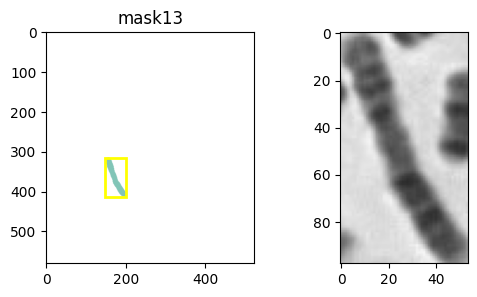

mask14
[29, 254, 48, 26]
[29, 77, 254, 280]


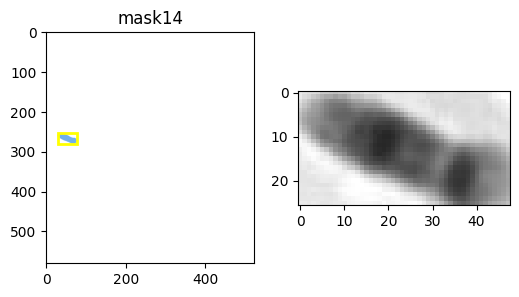

mask15
[223, 170, 61, 20]
[223, 284, 170, 190]


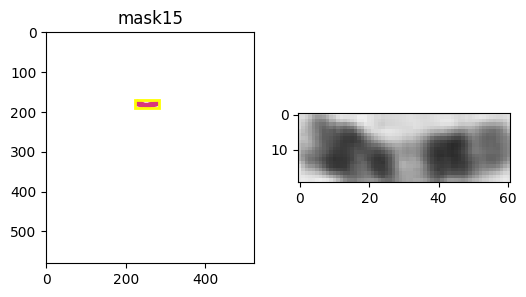

mask16
[229, 398, 55, 26]
[229, 284, 398, 424]


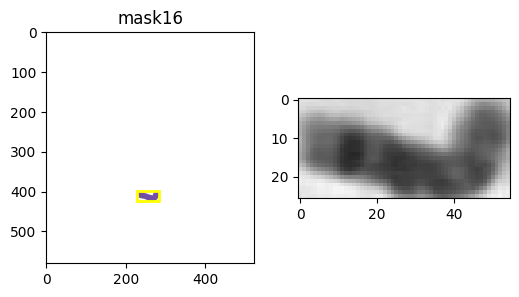

mask17
[189, 331, 15, 37]
[189, 204, 331, 368]


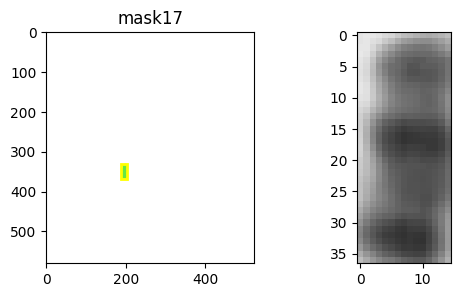

mask18
[242, 277, 56, 109]
[242, 298, 277, 386]


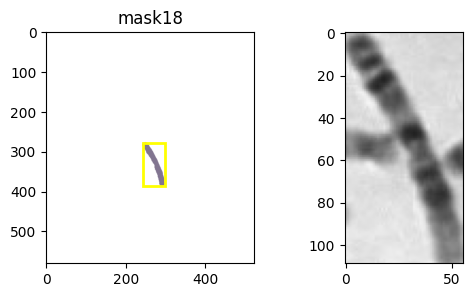

mask19
[242, 118, 83, 46]
[242, 325, 118, 164]


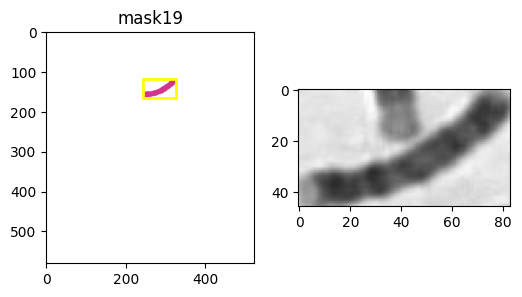

mask20
[99, 151, 44, 19]
[99, 143, 151, 170]


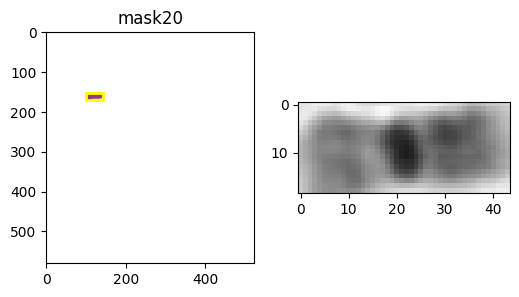

mask21
[123, 324, 26, 24]
[123, 149, 324, 348]


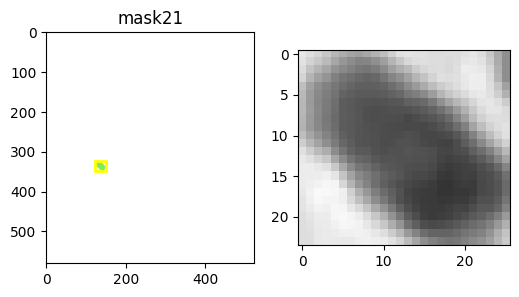

mask22
[382, 215, 77, 61]
[382, 459, 215, 276]


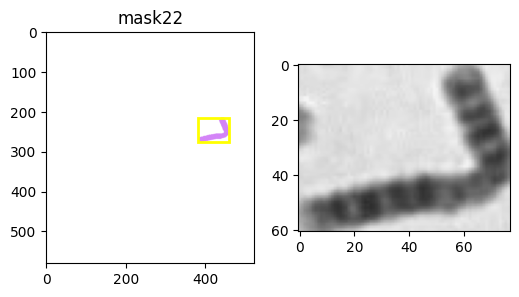

mask23
[341, 133, 60, 79]
[341, 401, 133, 212]


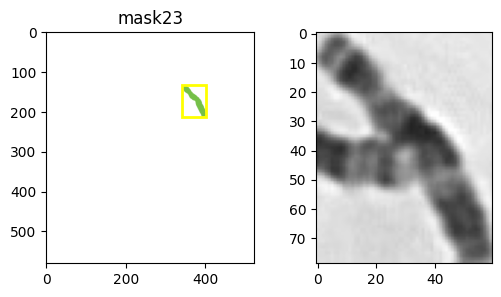

mask24
[289, 325, 31, 18]
[289, 320, 325, 343]


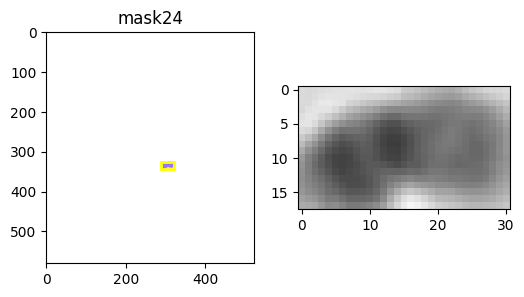

mask25
[81, 387, 29, 28]
[81, 110, 387, 415]


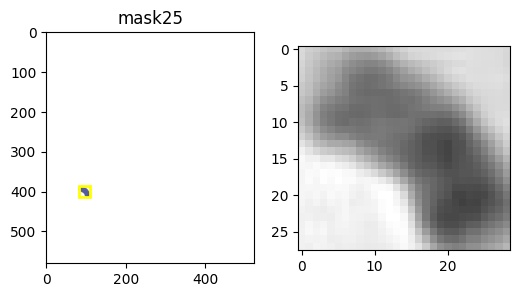

mask26
[211, 59, 34, 28]
[211, 245, 59, 87]


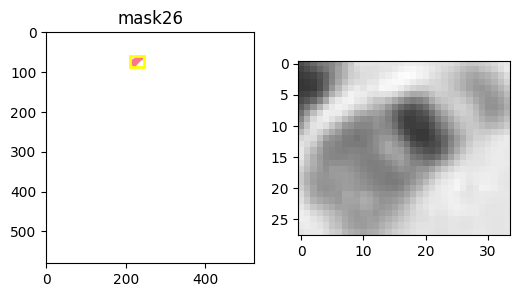

mask27
[81, 196, 34, 61]
[81, 115, 196, 257]


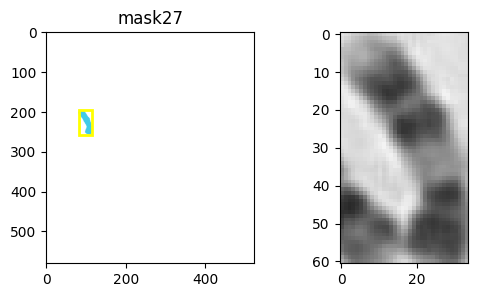

mask28
[62, 333, 23, 48]
[62, 85, 333, 381]


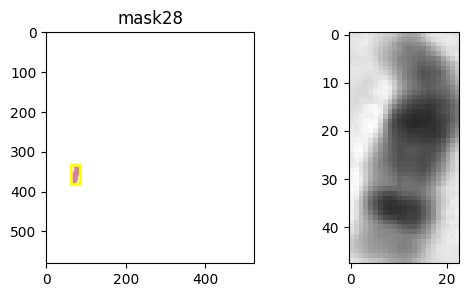

mask29
[92, 289, 59, 42]
[92, 151, 289, 331]


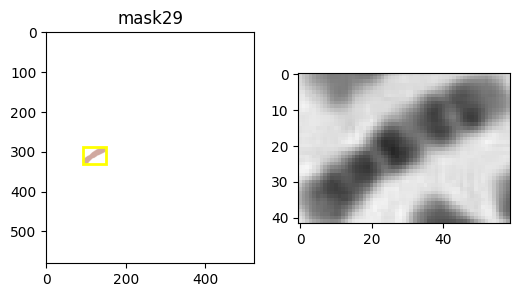

mask30
[324, 225, 62, 34]
[324, 386, 225, 259]


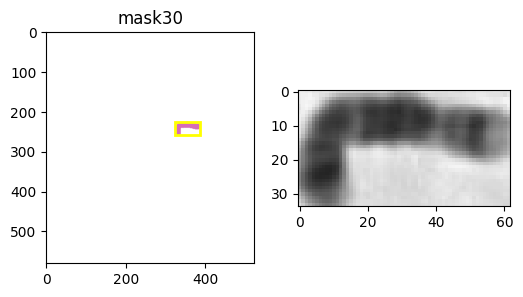

mask31
[103, 89, 67, 60]
[103, 170, 89, 149]


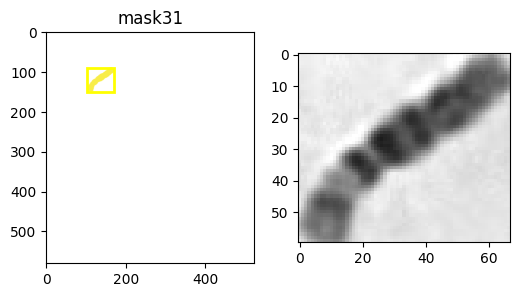

mask32
[296, 242, 14, 24]
[296, 310, 242, 266]


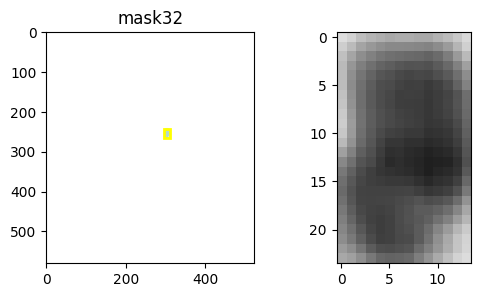

mask33
[108, 453, 46, 32]
[108, 154, 453, 485]


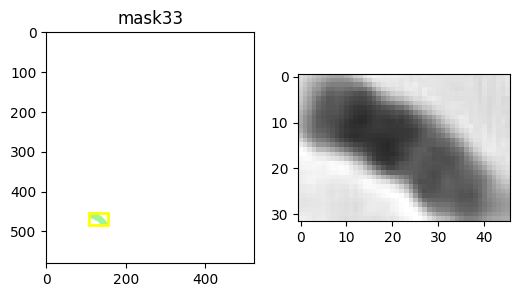

mask34
[95, 206, 100, 91]
[95, 195, 206, 297]


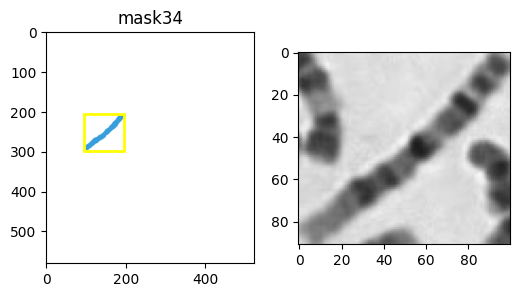

mask35
[453, 371, 17, 13]
[453, 470, 371, 384]


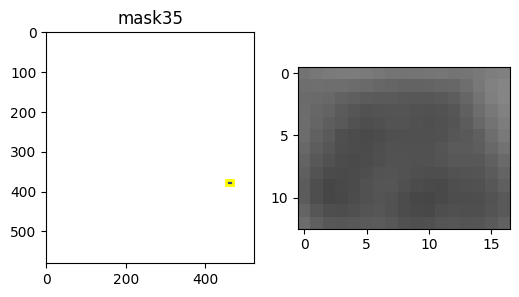

mask36
[175, 248, 22, 34]
[175, 197, 248, 282]


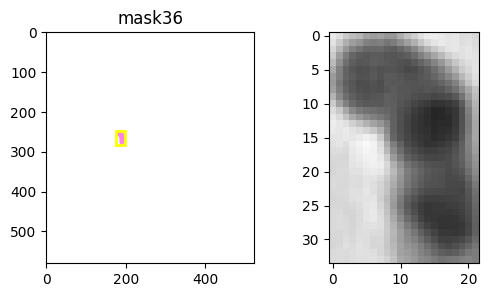

mask37
[270, 84, 31, 53]
[270, 301, 84, 137]


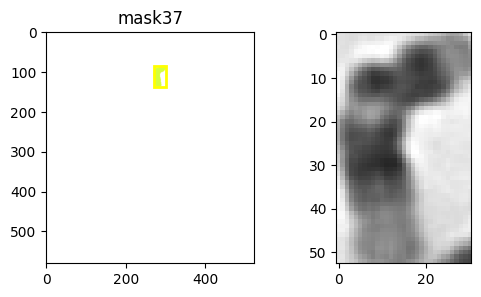

mask38
[260, 432, 39, 40]
[260, 299, 432, 472]


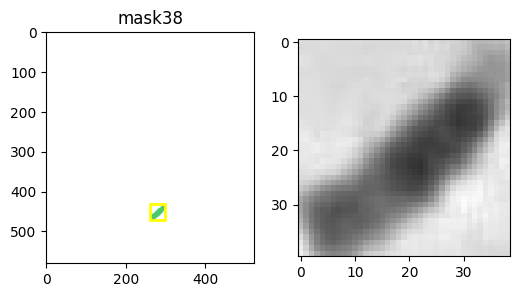

mask39
[114, 381, 38, 30]
[114, 152, 381, 411]


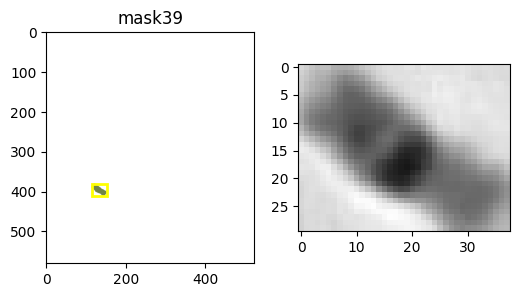

mask40
[39, 207, 57, 51]
[39, 96, 207, 258]


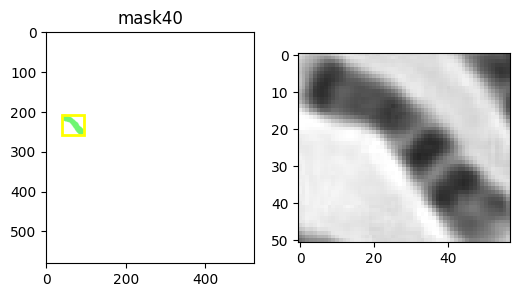

mask41
[248, 539, 28, 14]
[248, 276, 539, 553]


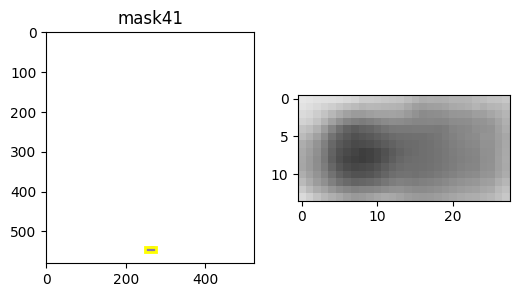

mask42
[219, 356, 23, 19]
[219, 242, 356, 375]


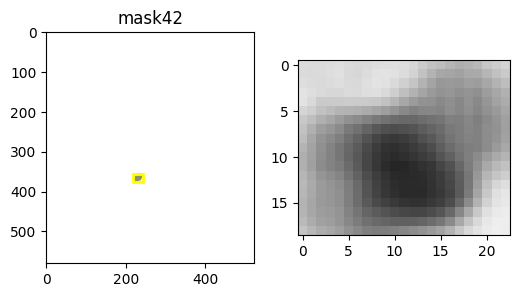

mask43
[44, 295, 29, 31]
[44, 73, 295, 326]


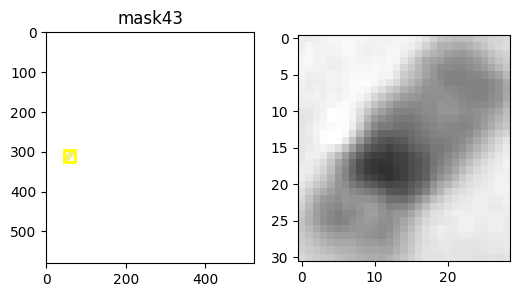

mask44
[299, 134, 101, 78]
[299, 400, 134, 212]


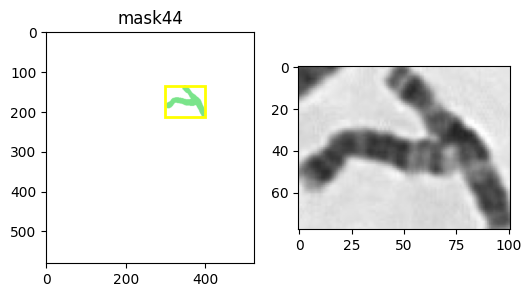

mask45
[382, 210, 116, 87]
[382, 498, 210, 297]


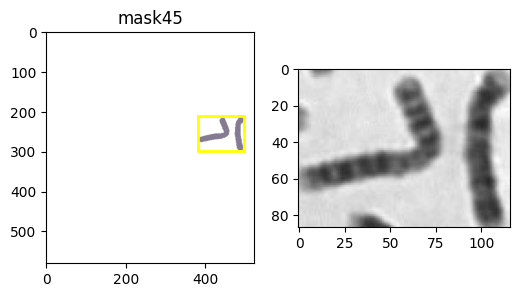

mask46
[223, 170, 28, 20]
[223, 251, 170, 190]


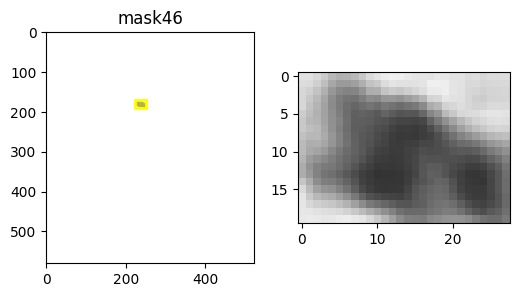

mask47
[379, 290, 59, 51]
[379, 438, 290, 341]


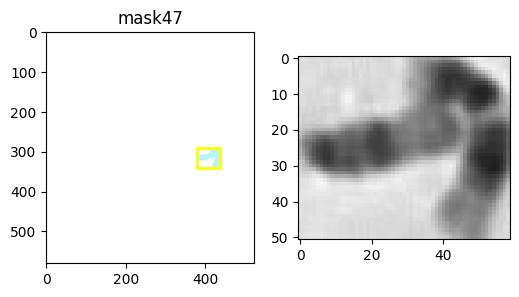

mask48
[319, 340, 65, 53]
[319, 384, 340, 393]


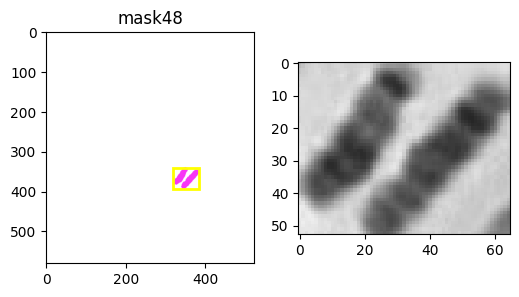

mask49
[206, 31, 21, 27]
[206, 227, 31, 58]


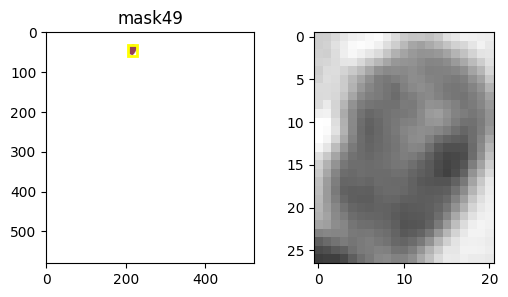

mask50
[140, 415, 30, 21]
[140, 170, 415, 436]


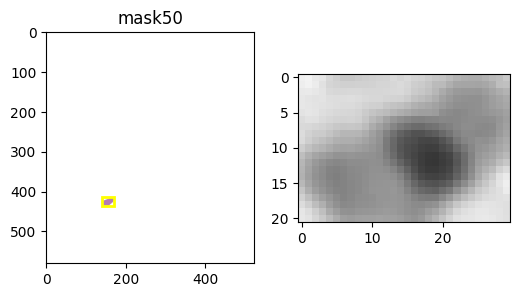

mask51
[227, 322, 93, 21]
[227, 320, 322, 343]


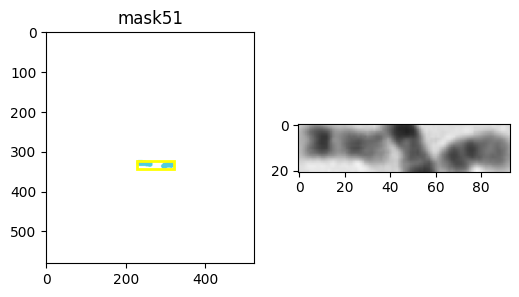

mask52
[228, 322, 38, 16]
[228, 266, 322, 338]


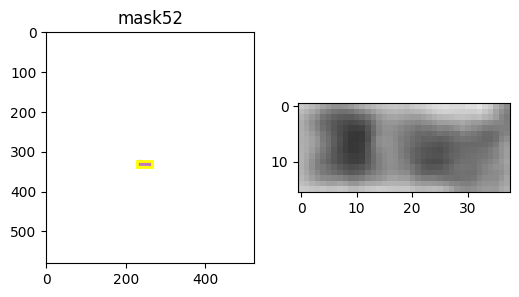

mask53
[150, 493, 25, 16]
[150, 175, 493, 509]


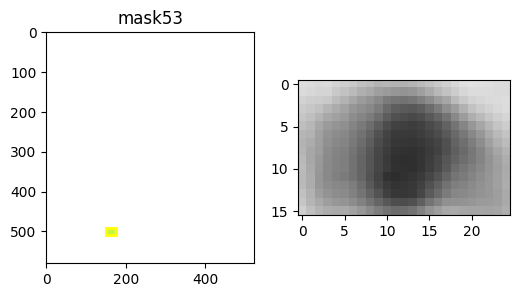

mask54
[298, 164, 76, 28]
[298, 374, 164, 192]


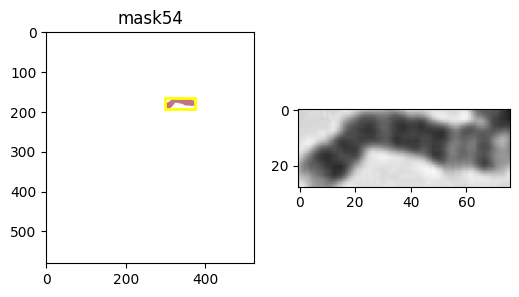

mask55
[99, 153, 18, 18]
[99, 117, 153, 171]


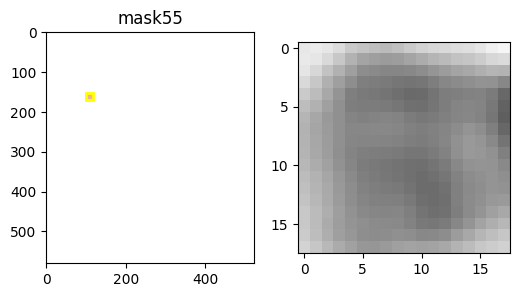

mask56
[402, 421, 11, 10]
[402, 413, 421, 431]


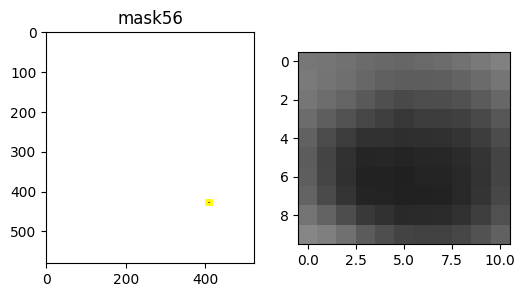

mask57
[157, 443, 24, 32]
[157, 181, 443, 475]


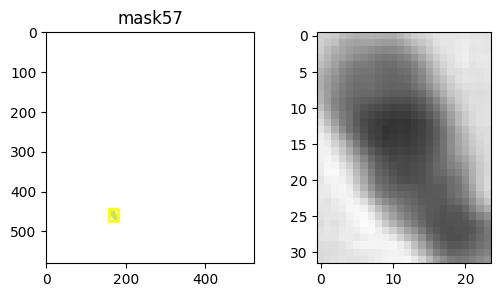

mask58
[186, 53, 30, 39]
[186, 216, 53, 92]


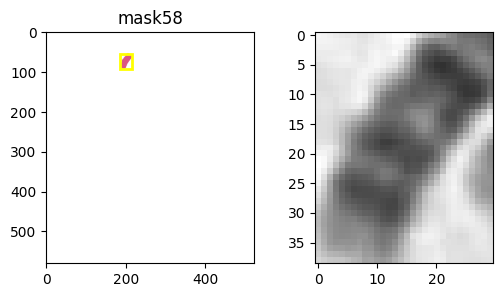

mask59
[210, 490, 16, 32]
[210, 226, 490, 522]


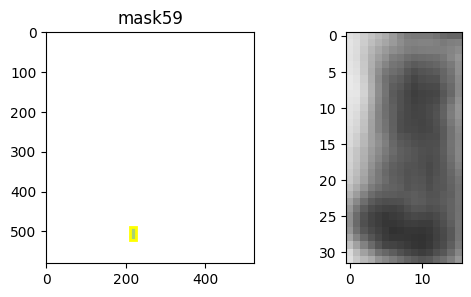

mask60
[379, 303, 45, 19]
[379, 424, 303, 322]


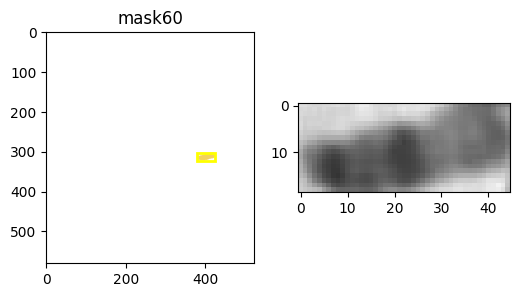

mask61
[303, 273, 24, 17]
[303, 327, 273, 290]


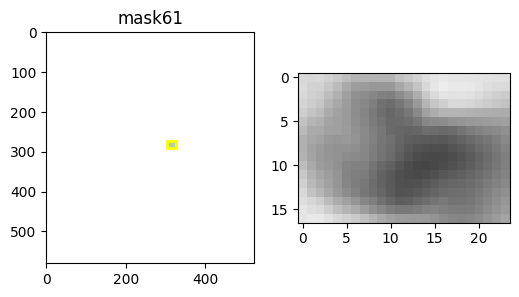

mask62
[1, 183, 27, 30]
[1, 28, 183, 213]


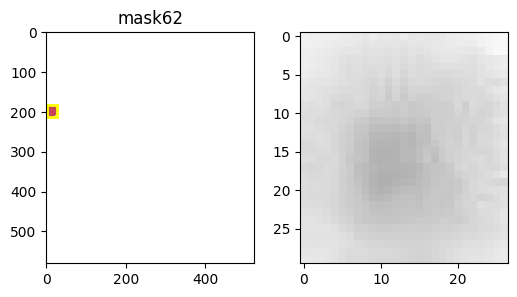

mask63
[467, 149, 5, 5]
[467, 472, 149, 154]


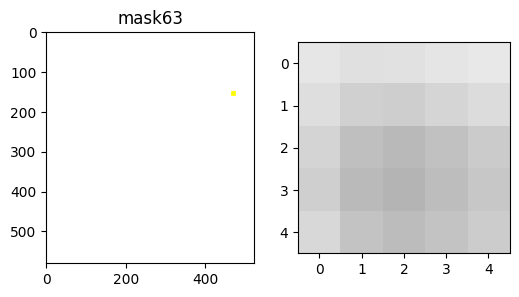

mask64
[227, 277, 93, 109]
[227, 320, 277, 386]


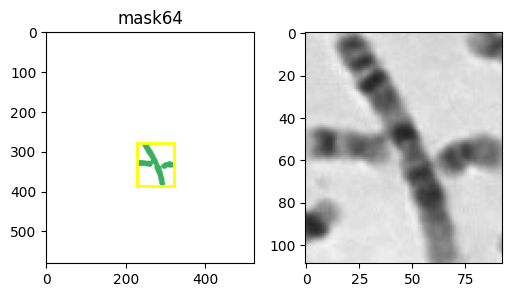

mask65
[147, 257, 89, 157]
[147, 236, 257, 414]


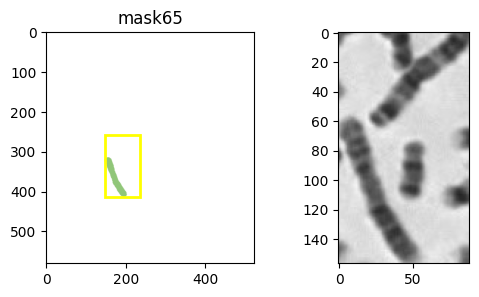

mask66
[103, 131, 17, 18]
[103, 120, 131, 149]


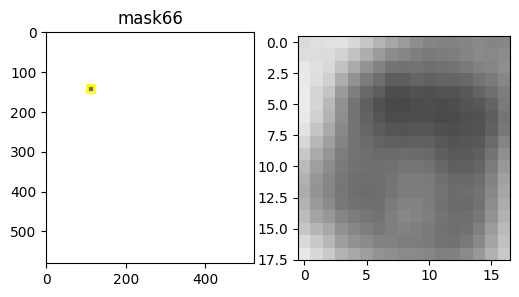

mask67
[116, 151, 27, 16]
[116, 143, 151, 167]


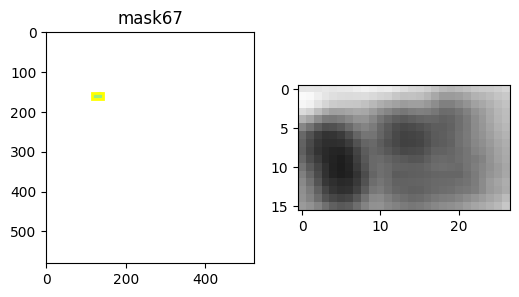

mask68
[411, 290, 27, 51]
[411, 438, 290, 341]


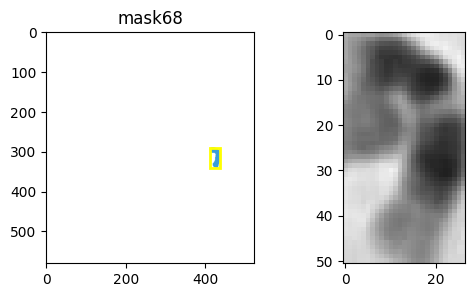

mask69
[140, 420, 26, 17]
[140, 166, 420, 437]


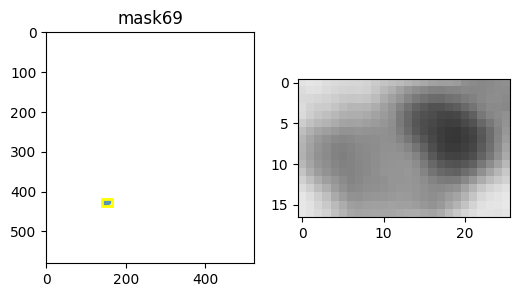

mask70
[99, 89, 71, 81]
[99, 170, 89, 170]


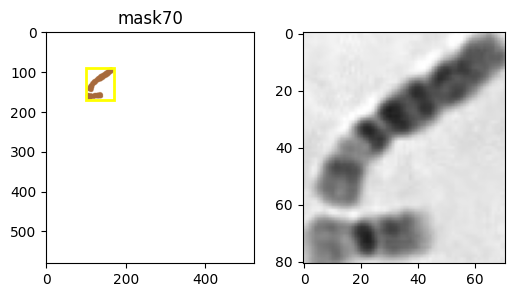

mask71
[329, 276, 17, 14]
[329, 346, 276, 290]


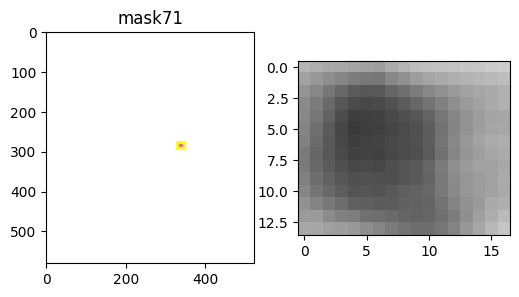

mask72
[29, 254, 34, 22]
[29, 63, 254, 276]


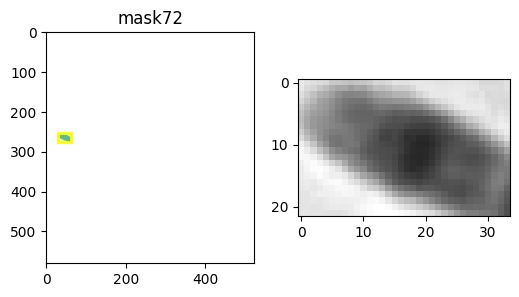

mask73
[434, 215, 25, 44]
[434, 459, 215, 259]


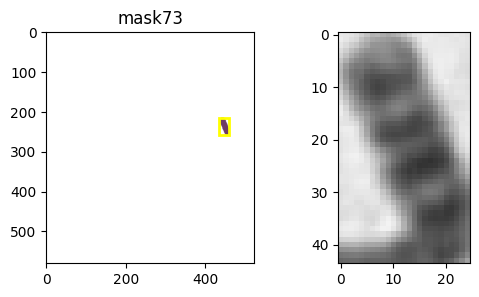

mask74
[181, 13, 29, 27]
[181, 210, 13, 40]


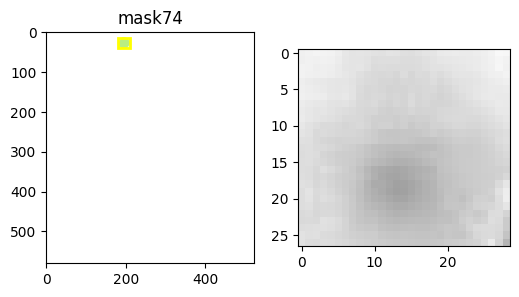

mask75
[114, 381, 25, 23]
[114, 139, 381, 404]


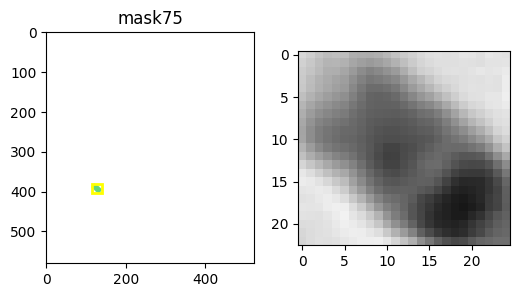

mask76
[178, 473, 26, 30]
[178, 204, 473, 503]


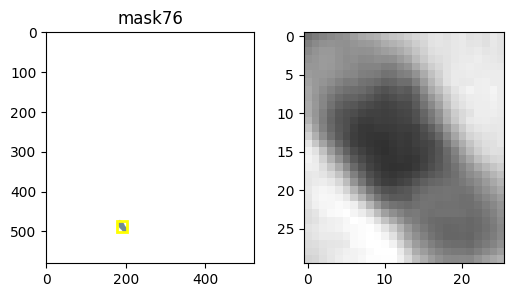

mask77
[417, 300, 21, 42]
[417, 438, 300, 342]


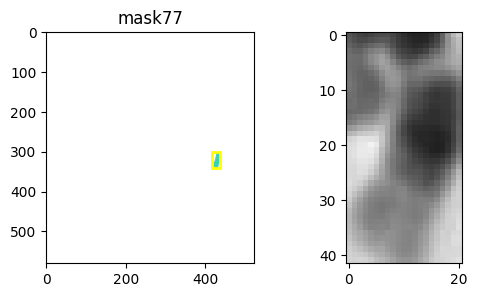

mask78
[344, 63, 9, 6]
[344, 353, 63, 69]


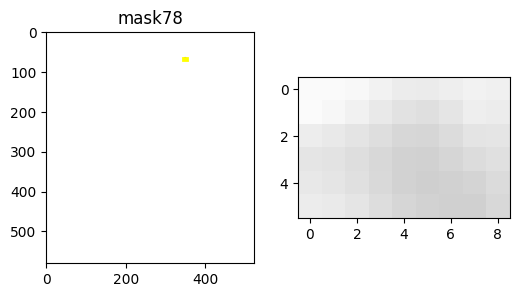

mask79
[270, 45, 75, 92]
[270, 345, 45, 137]


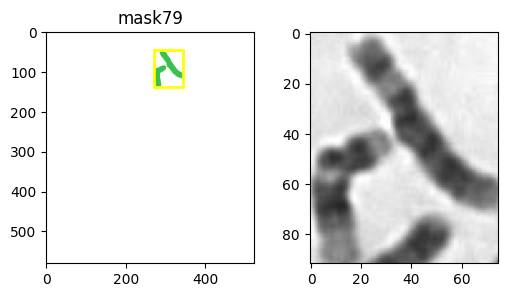

mask80
[380, 7, 8, 4]
[380, 388, 7, 11]


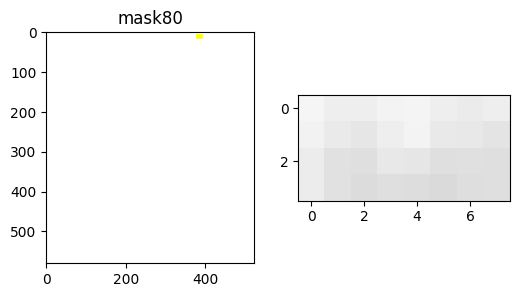

mask81
[255, 246, 40, 19]
[255, 295, 246, 265]


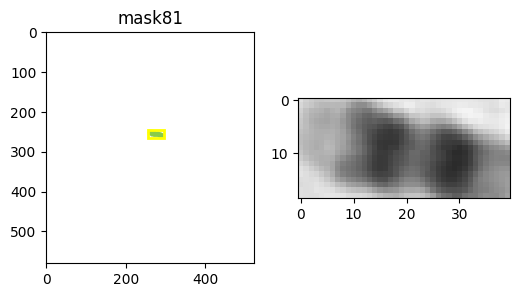

mask82
[212, 63, 24, 24]
[212, 236, 63, 87]


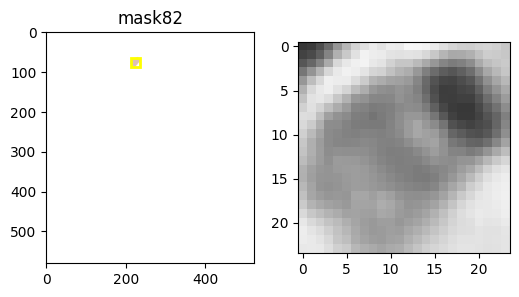

mask83
[380, 6, 9, 6]
[380, 389, 6, 12]


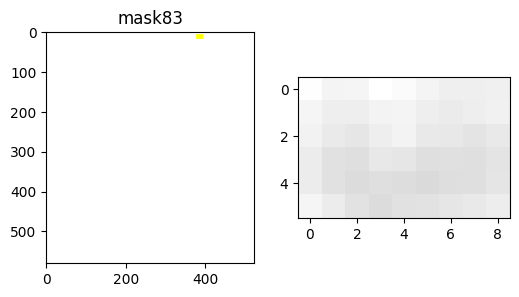

mask84
[5, 185, 21, 25]
[5, 26, 185, 210]


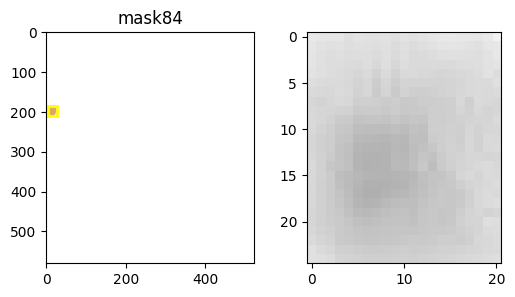

mask85
[381, 253, 72, 23]
[381, 453, 253, 276]


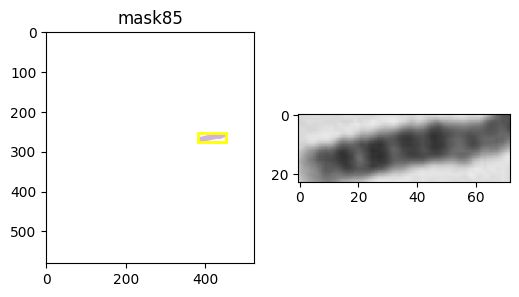

mask86
[217, 452, 15, 26]
[217, 232, 452, 478]


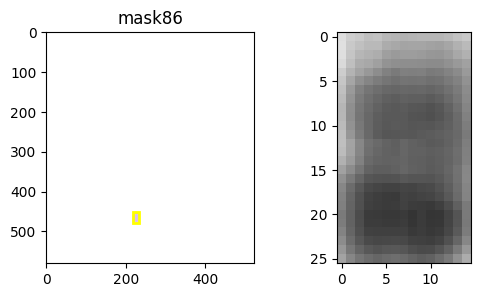

In [ ]:
#show slices of masks1
for i in range(len(masks1)):
    fig, ax = plt.subplots(1,2,figsize=(6,3))
    ax[0].imshow(bgw)
    masksi=masks1[i]
    box0=masksi['bbox']
    xc,yc,w,h = box0
    x0=xc
    y0=yc
    x1=xc+w
    y1=yc+h
    print(f'mask{i}')
    print(box0)
    print([x0,x1,y0,y1])
    rect = patches.Rectangle( (xc,yc),w,h, linewidth=2, edgecolor='yellow', fill=False)

    boximage=image[y0:y1,x0:x1,:]
    cv2.imwrite(str(i).zfill(3)+'.png', boximage)

    show_anns([masksi],ax[0])
    ax[0].add_patch(rect)
    ax[1].imshow(boximage)
    ax[0].set_title(f'mask{i}')
    plt.show()

In [ ]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import os

# Reemplazamos la ruta estática de Kaggle por la ruta de descarga local de kagglehub
patha0 = os.path.join(path, 'Data/24_chromosomes_object/annotations/103064.xml')

image = cv2.imread(path0)
tree = ET.parse(patha0)

In [ ]:
for elem in tree.iter():
    if 'object' in elem.tag:
        for attr in list(elem):
            if 'name' in attr.tag:
                name = attr.text
            if 'bndbox' in attr.tag:
                for dim in list(attr):
                    if 'xmin' in dim.tag:
                        xmin = int(round(float(dim.text)))
                    if 'ymin' in dim.tag:
                        ymin = int(round(float(dim.text)))
                    if 'xmax' in dim.tag:
                        xmax = int(round(float(dim.text)))
                    if 'ymax' in dim.tag:
                        ymax = int(round(float(dim.text)))

                cv2.rectangle(image,(xmin,ymin),(xmax,ymax), (255,0,0),1)
                cv2.putText(image,name,(xmin+10, ymin+15),
                        cv2.FONT_HERSHEY_SIMPLEX, 1e-3*image.shape[0],(255,0,0),1)

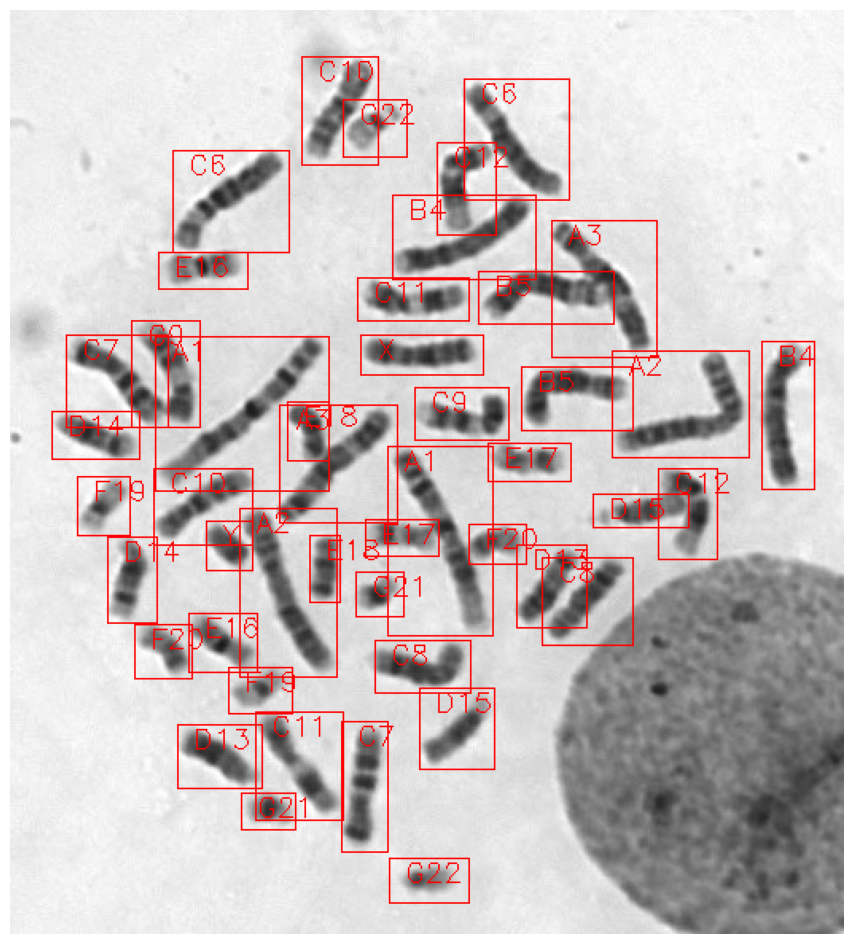

In [ ]:
plt.figure(figsize=(12,12))
plt.imshow(image)
plt.axis('off')
plt.show()

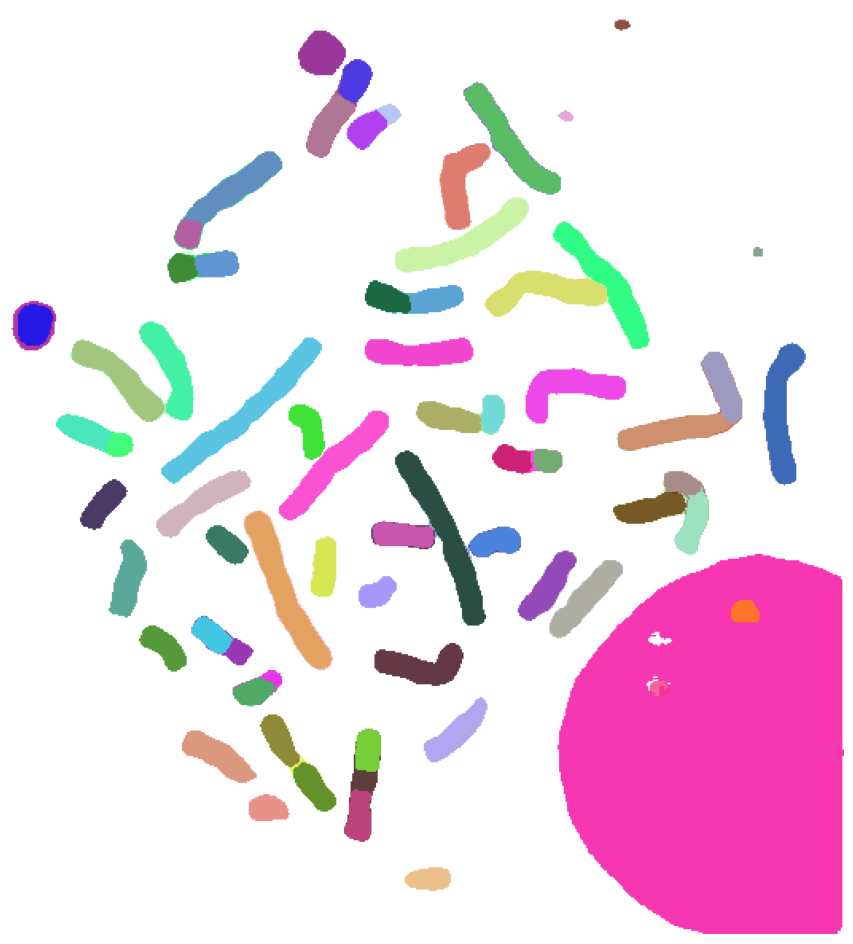

In [ ]:
fig, axs = plt.subplots(figsize=(12,12))
show_anns(masks1,axs)
axs.axis('off')
plt.show()
fig.savefig('save.png', bbox_inches='tight')

1/4 Localizando dataset...
Using Colab cache for faster access to the 'chromosome-image-dataset-karyotype' dataset.
    imagen (581, 524, 3), 46 cajas anotadas
2/4 Cargando SAM...
Descargando checkpoint de SAM (puede tardar unos minutos)...
3/4 Generando máscaras de la imagen principal...
    87 máscaras totales, 82 tras filtrar por área
4/4 Creando figuras...


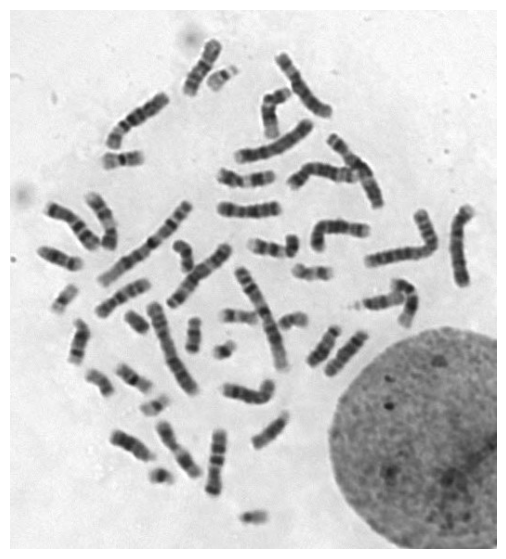

  -> figuras_cromosomas/01_original.png


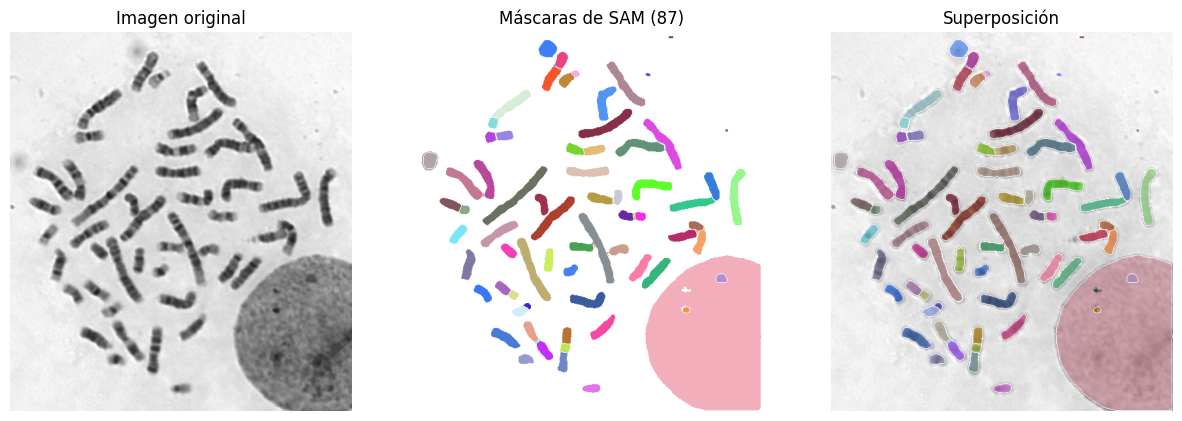

  -> figuras_cromosomas/02_tres_paneles.png


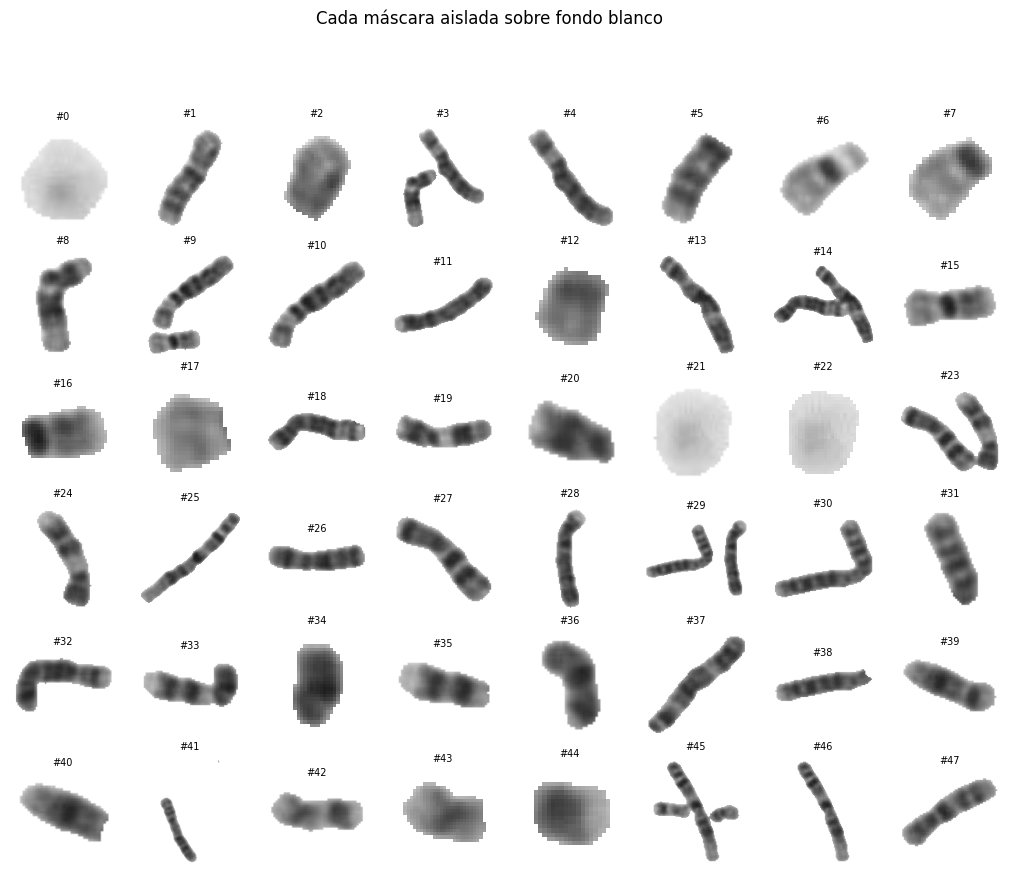

  -> figuras_cromosomas/03_recortes_sin_fondo.png


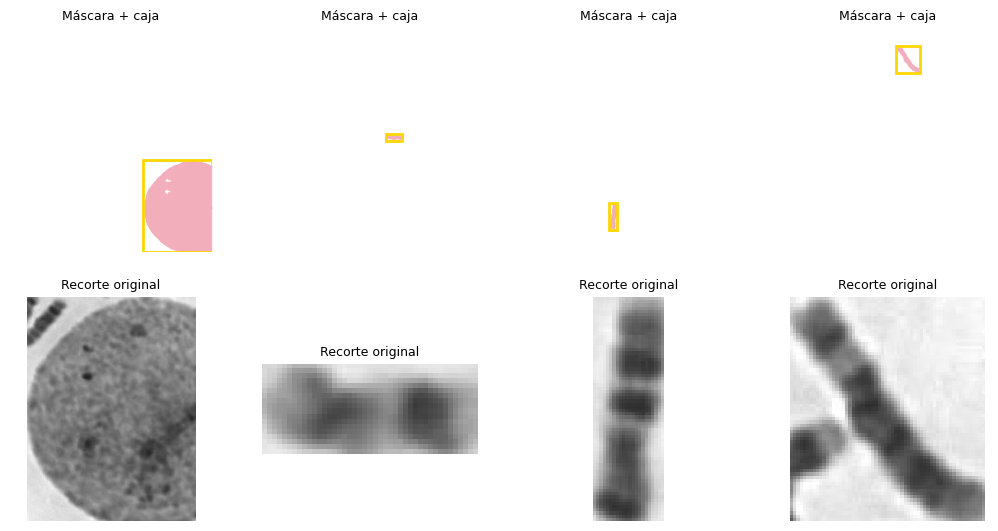

  -> figuras_cromosomas/04_mascara_bbox_recorte.png


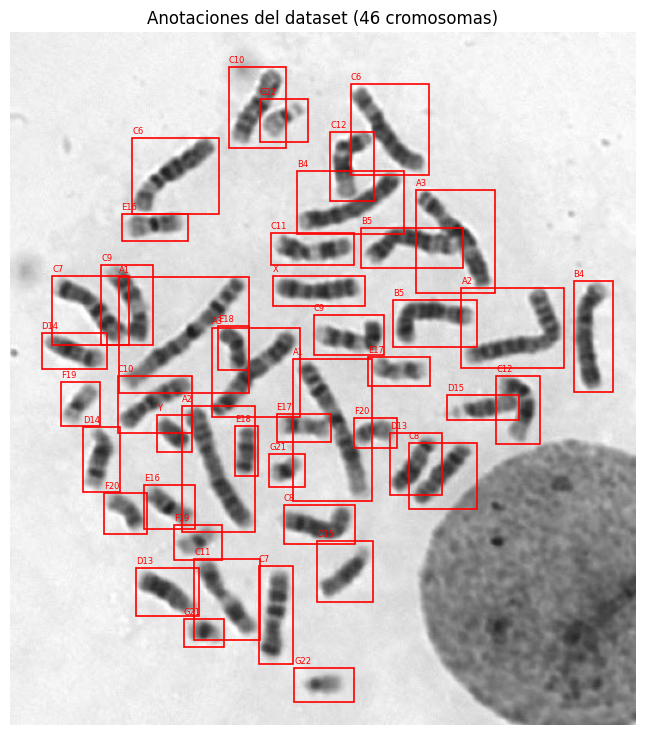

  -> figuras_cromosomas/05_anotaciones_xml.png


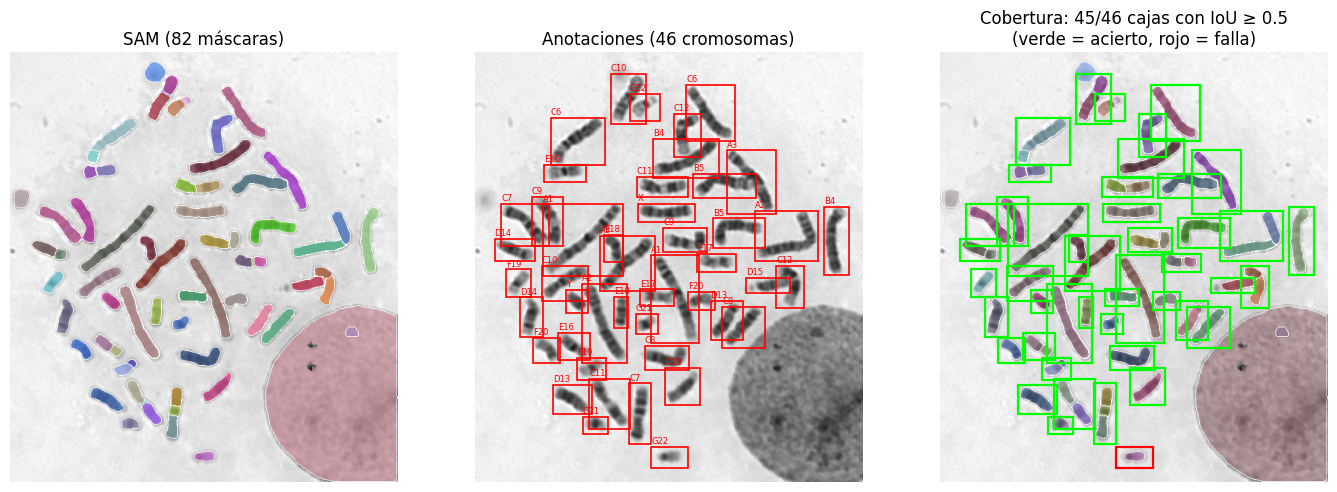

  -> figuras_cromosomas/06_sam_vs_anotaciones.png


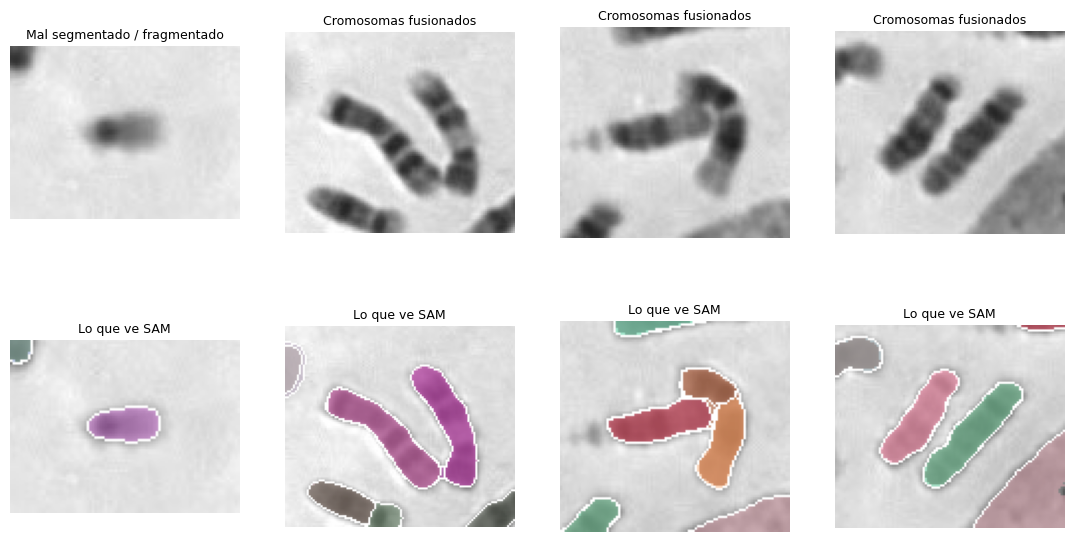

  -> figuras_cromosomas/08_casos_dificiles.png


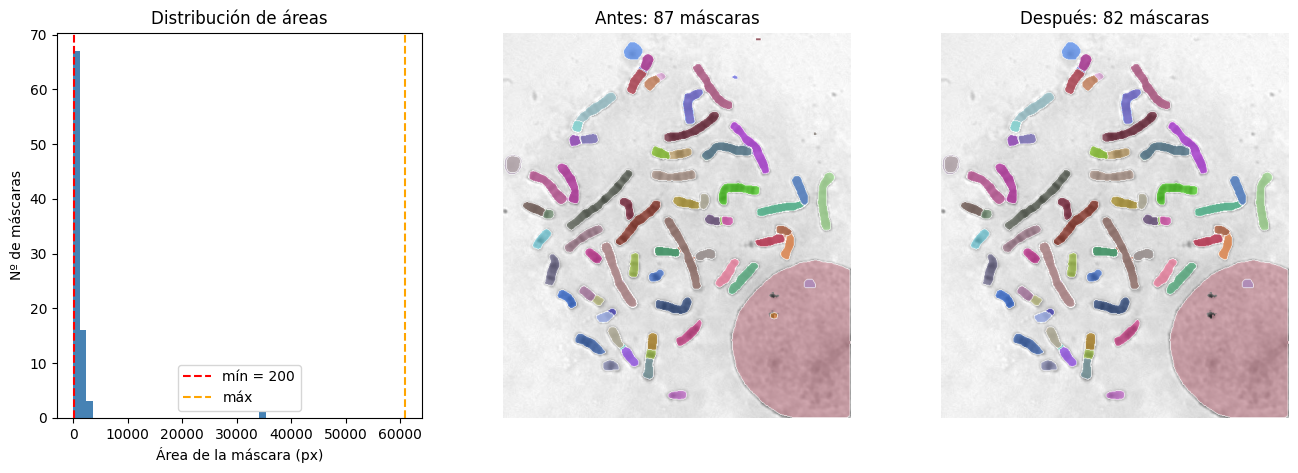

  -> figuras_cromosomas/07_filtro_por_area.png


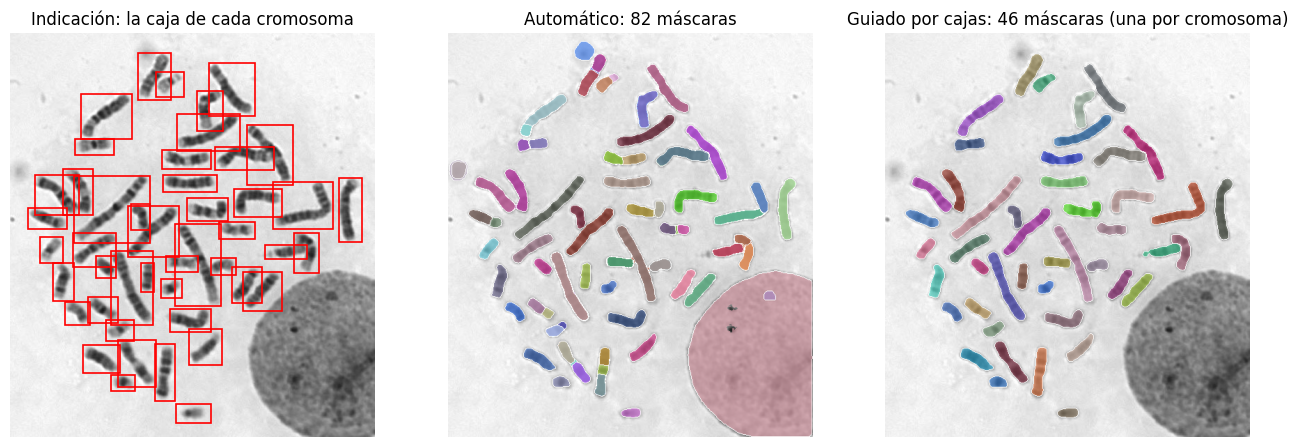

  -> figuras_cromosomas/10_sam_guiado_por_cajas.png
  procesando 1057584.jpg
  procesando 1053443.jpg
  procesando 1070771.jpg
  procesando 1050343_1.jpg


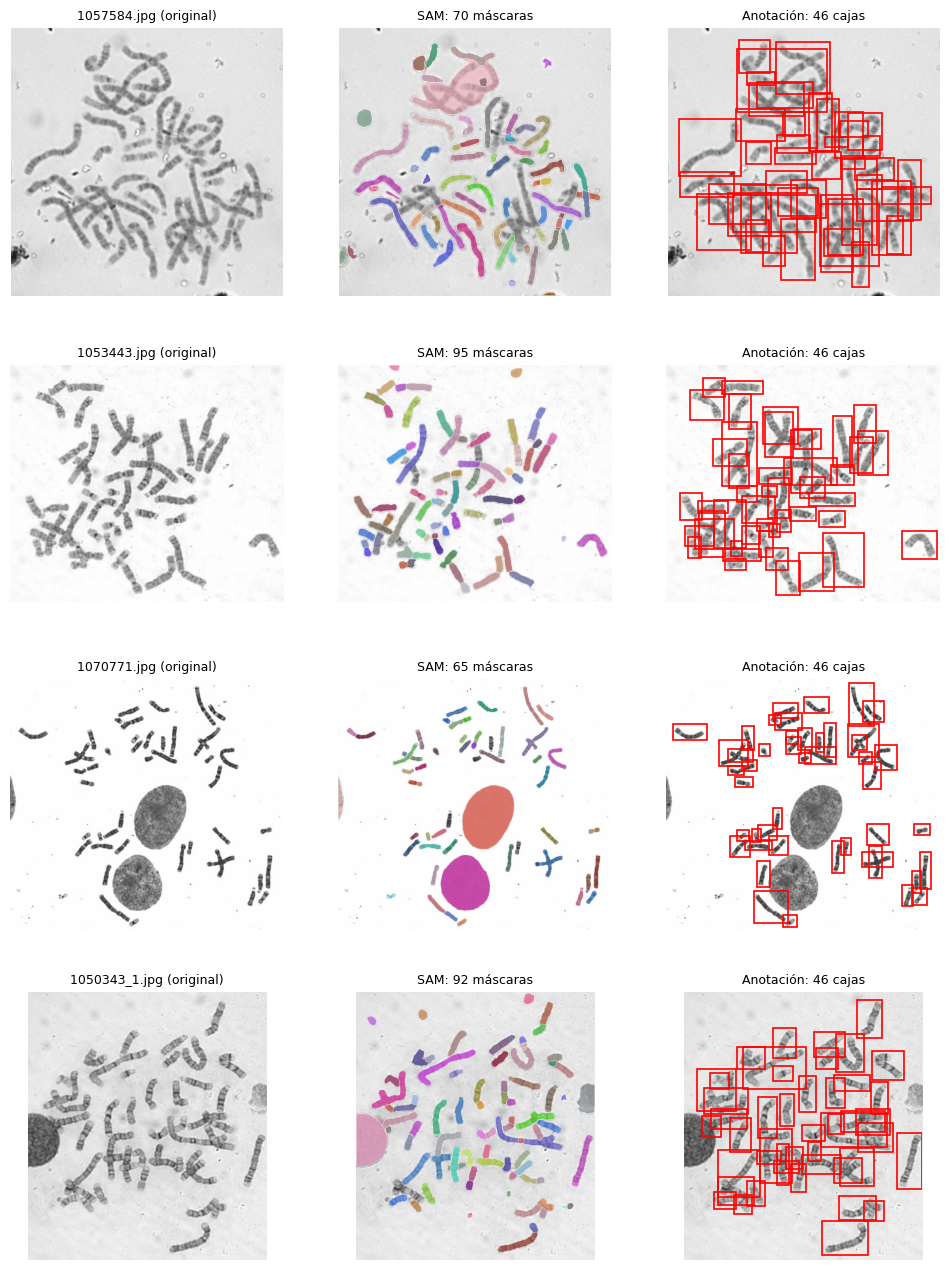

  -> figuras_cromosomas/09_galeria_dataset.png
  -> 82 recortes en figuras_cromosomas/recortes
  -> figuras_cromosomas/video_mascaras.mp4
Listo. Revisa la carpeta: /content/figuras_cromosomas


In [3]:
import os
import sys
import random
import urllib.request
import xml.etree.ElementTree as ET

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----------------------------------------------------------------------------
# CONFIGURACIÓN (ajusta aquí)
# ----------------------------------------------------------------------------
KAGGLE_DATASET = "aliabedimadiseh/chromosome-image-dataset-karyotype"
MAIN_IMAGE_ID = "103064"          # imagen principal (la del notebook)
N_GALLERY = 4                     # cuántas imágenes extra en la galería
SEED = 7                          # semilla para colores y selección aleatoria
OUT_DIR = "figuras_cromosomas"
DPI = 200

SAM_CHECKPOINT = "sam_vit_h_4b8939.pth"
SAM_MODEL_TYPE = "vit_h"
SAM_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"

# Filtro de máscaras por área (punto de partida; revisa el histograma 07)
MIN_AREA = 200                    # descarta fragmentos más pequeños (píxeles)
MAX_AREA_FRAC = 0.20              # descarta máscaras más grandes que esta fracción de la imagen
IOU_MATCH = 0.5                   # umbral para dar por "acertada" una caja anotada

SAVE_CUTOUTS = True               # guardar PNG transparente de cada cromosoma
MAKE_VIDEO = True
VIDEO_FPS = 6

# Dentro de Jupyter/Colab se muestran las figuras en línea
SHOW = "ipykernel" in sys.modules
if not SHOW:
    matplotlib.use("Agg")


# ----------------------------------------------------------------------------
# UTILIDADES GENERALES
# ----------------------------------------------------------------------------
def save_fig(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight", facecolor="white")
    if SHOW:
        plt.show()
    plt.close(fig)
    print("  ->", path)


def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV carga BGR; SAM espera RGB


def _child(el, tag):
    for c in list(el):
        if c.tag.endswith(tag):
            return c
    return None


def load_boxes(xml_path):
    """Lee anotaciones tipo Pascal VOC -> lista de (clase, xmin, ymin, xmax, ymax)."""
    boxes = []
    if not os.path.exists(xml_path):
        return boxes
    root = ET.parse(xml_path).getroot()
    for obj in root.iter():
        if not obj.tag.endswith("object"):
            continue
        name_el, bb = _child(obj, "name"), _child(obj, "bndbox")
        if bb is None:
            continue
        vals = []
        for k in ("xmin", "ymin", "xmax", "ymax"):
            vals.append(int(round(float(_child(bb, k).text))))
        boxes.append((name_el.text if name_el is not None else "?", *vals))
    return boxes


def bbox_xyxy(ann):
    x, y, w, h = [int(round(v)) for v in ann["bbox"]]  # SAM entrega XYWH
    return x, y, x + w, y + h


def iou_xyxy(a, b):
    ix0, iy0 = max(a[0], b[0]), max(a[1], b[1])
    ix1, iy1 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix1 - ix0) * max(0, iy1 - iy0)
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / float(area_a + area_b - inter)


def filter_masks(anns, shape):
    max_area = MAX_AREA_FRAC * shape[0] * shape[1]
    return [a for a in anns if MIN_AREA < a["area"] < max_area]


# ----------------------------------------------------------------------------
# DIBUJO
# ----------------------------------------------------------------------------
def overlay_masks(image, anns, alpha=0.6, seed=SEED):
    """Pinta cada máscara con un color distinto (colores reproducibles)."""
    rng = np.random.default_rng(seed)
    out = image.astype(np.float32).copy()
    for ann in sorted(anns, key=lambda a: a["area"], reverse=True):
        m = ann["segmentation"]
        color = rng.integers(40, 255, 3).astype(np.float32)
        out[m] = (1 - alpha) * out[m] + alpha * color
        cnts, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        tmp = out.astype(np.uint8)
        cv2.drawContours(tmp, cnts, -1, (255, 255, 255), 1)
        out = tmp.astype(np.float32)
    return out.astype(np.uint8)


def masks_only(image, anns, seed=SEED):
    """Solo las máscaras de colores sobre fondo blanco (sin la imagen)."""
    white = np.full_like(image, 255)
    return overlay_masks(white, anns, alpha=1.0, seed=seed)


def cutout_on_white(image, ann, pad=4):
    """Recorte del cromosoma con el fondo blanco (usa los píxeles originales)."""
    canvas = np.full_like(image, 255)
    m = ann["segmentation"]
    canvas[m] = image[m]
    x0, y0, x1, y1 = bbox_xyxy(ann)
    h, w = image.shape[:2]
    return canvas[max(0, y0 - pad):min(h, y1 + pad), max(0, x0 - pad):min(w, x1 + pad)]


def draw_gt_boxes(ax, boxes, color="red", labels=True, lw=1.2):
    for (name, x0, y0, x1, y1) in boxes:
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                       linewidth=lw, edgecolor=color, fill=False))
        if labels:
            ax.text(x0, y0 - 2, name, color=color, fontsize=6, va="bottom")


def match_boxes(anns, boxes):
    """Para cada caja anotada busca la máscara de SAM con mayor IoU de caja."""
    results = []
    for b in boxes:
        gt = b[1:]
        best, best_i = 0.0, -1
        for i, a in enumerate(anns):
            v = iou_xyxy(gt, bbox_xyxy(a))
            if v > best:
                best, best_i = v, i
        results.append((best, best_i))
    return results


# ----------------------------------------------------------------------------
# MODELO SAM
# ----------------------------------------------------------------------------
def load_sam():
    import torch
    from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cpu":
        print("AVISO: no hay GPU; SAM vit_h en CPU será muy lento.")
    if not os.path.exists(SAM_CHECKPOINT):
        print("Descargando checkpoint de SAM (puede tardar unos minutos)...")
        urllib.request.urlretrieve(SAM_URL, SAM_CHECKPOINT)
    sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
    sam.to(device=device)
    return sam, SamAutomaticMaskGenerator(sam), SamPredictor(sam)


def locate_dataset():
    import kagglehub
    root = kagglehub.dataset_download(KAGGLE_DATASET)
    base = os.path.join(root, "Data", "24_chromosomes_object")
    img_dir = os.path.join(base, "JEPG")            # así se llama la carpeta en el dataset
    if not os.path.isdir(img_dir):
        img_dir = os.path.join(base, "JPEG")
    ann_dir = os.path.join(base, "annotations")
    return img_dir, ann_dir


# ----------------------------------------------------------------------------
# FIGURAS
# ----------------------------------------------------------------------------
def fig01_original(image):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(image)
    ax.axis("off")
    save_fig(fig, "01_original.png")


def fig02_tres_paneles(image, anns):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(image)
    axs[0].set_title("Imagen original")
    axs[1].imshow(masks_only(image, anns))
    axs[1].set_title(f"Máscaras de SAM ({len(anns)})")
    axs[2].imshow(overlay_masks(image, anns))
    axs[2].set_title("Superposición")
    for a in axs:
        a.axis("off")
    save_fig(fig, "02_tres_paneles.png")


def fig03_recortes_sin_fondo(image, anns, cols=8, max_n=48):
    sel = sorted(anns, key=lambda a: (a["bbox"][1], a["bbox"][0]))[:max_n]
    rows = int(np.ceil(len(sel) / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
    axs = np.atleast_2d(axs)
    for k, ax in enumerate(axs.ravel()):
        ax.axis("off")
        if k < len(sel):
            ax.imshow(cutout_on_white(image, sel[k]))
            ax.set_title(f"#{k}", fontsize=7)
    fig.suptitle("Cada máscara aislada sobre fondo blanco", y=1.0)
    save_fig(fig, "03_recortes_sin_fondo.png")


def fig04_mascara_bbox_recorte(image, anns, n=4):
    sel = sorted(anns, key=lambda a: a["predicted_iou"], reverse=True)[:n]
    fig, axs = plt.subplots(2, n, figsize=(3.2 * n, 6.4))
    axs = np.atleast_2d(axs).reshape(2, -1)
    for k, ann in enumerate(sel):
        x0, y0, x1, y1 = bbox_xyxy(ann)
        axs[0, k].imshow(overlay_masks(np.full_like(image, 255), [ann], alpha=1.0))
        axs[0, k].add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                              linewidth=2, edgecolor="gold", fill=False))
        axs[0, k].set_title("Máscara + caja", fontsize=9)
        axs[1, k].imshow(image[y0:y1, x0:x1])
        axs[1, k].set_title("Recorte original", fontsize=9)
        axs[0, k].axis("off")
        axs[1, k].axis("off")
    save_fig(fig, "04_mascara_bbox_recorte.png")


def fig05_anotaciones(image, boxes):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(image)
    draw_gt_boxes(ax, boxes, color="red")
    ax.set_title(f"Anotaciones del dataset ({len(boxes)} cromosomas)")
    ax.axis("off")
    save_fig(fig, "05_anotaciones_xml.png")


def fig06_sam_vs_anotaciones(image, anns, boxes):
    res = match_boxes(anns, boxes)
    ok = sum(1 for v, _ in res if v >= IOU_MATCH)
    fig, axs = plt.subplots(1, 3, figsize=(17, 6))
    axs[0].imshow(overlay_masks(image, anns))
    axs[0].set_title(f"SAM ({len(anns)} máscaras)")
    axs[1].imshow(image)
    draw_gt_boxes(axs[1], boxes, color="red")
    axs[1].set_title(f"Anotaciones ({len(boxes)} cromosomas)")
    axs[2].imshow(overlay_masks(image, anns, alpha=0.35))
    for b, (v, _) in zip(boxes, res):
        draw_gt_boxes(axs[2], [b], color="lime" if v >= IOU_MATCH else "red", labels=False, lw=1.6)
    axs[2].set_title(f"Cobertura: {ok}/{len(boxes)} cajas con IoU ≥ {IOU_MATCH}\n(verde = acierto, rojo = falla)")
    for a in axs:
        a.axis("off")
    save_fig(fig, "06_sam_vs_anotaciones.png")
    return res


def fig07_filtro_por_area(image, anns):
    kept = filter_masks(anns, image.shape)
    areas = np.array([a["area"] for a in anns])
    fig = plt.figure(figsize=(16, 5))
    ax0 = fig.add_subplot(1, 3, 1)
    ax0.hist(areas, bins=30, color="steelblue")
    ax0.axvline(MIN_AREA, color="red", ls="--", label=f"mín = {MIN_AREA}")
    ax0.axvline(MAX_AREA_FRAC * image.shape[0] * image.shape[1], color="orange", ls="--", label="máx")
    ax0.set_xlabel("Área de la máscara (px)")
    ax0.set_ylabel("Nº de máscaras")
    ax0.set_title("Distribución de áreas")
    ax0.legend()
    ax1 = fig.add_subplot(1, 3, 2)
    ax1.imshow(overlay_masks(image, anns))
    ax1.set_title(f"Antes: {len(anns)} máscaras")
    ax1.axis("off")
    ax2 = fig.add_subplot(1, 3, 3)
    ax2.imshow(overlay_masks(image, kept))
    ax2.set_title(f"Después: {len(kept)} máscaras")
    ax2.axis("off")
    save_fig(fig, "07_filtro_por_area.png")
    return kept


def fig08_casos_dificiles(image, anns, boxes, res, max_cases=4):
    cases = []
    # 1) cajas anotadas sin buena coincidencia (cromosoma fragmentado o no detectado)
    for b, (v, _) in zip(boxes, res):
        if v < IOU_MATCH:
            cases.append(("Mal segmentado / fragmentado", b[1:]))
    # 2) máscaras que cubren el centro de 2 o más cromosomas (fusionados)
    for a in anns:
        inside = []
        for b in boxes:
            cx, cy = (b[1] + b[3]) // 2, (b[2] + b[4]) // 2
            if 0 <= cy < a["segmentation"].shape[0] and 0 <= cx < a["segmentation"].shape[1] \
                    and a["segmentation"][cy, cx]:
                inside.append(b)
        if len(inside) >= 2:
            cases.append(("Cromosomas fusionados", bbox_xyxy(a)))
    if not cases:
        print("  (no se encontraron casos difíciles con los umbrales actuales; se omite la figura 08)")
        return
    cases = cases[:max_cases]
    over = overlay_masks(image, anns, alpha=0.45)
    h, w = image.shape[:2]
    fig, axs = plt.subplots(2, len(cases), figsize=(3.4 * len(cases), 7))
    axs = np.atleast_2d(axs).reshape(2, -1)
    for k, (label, (x0, y0, x1, y1)) in enumerate(cases):
        p = 20
        xs, xe, ys, ye = max(0, x0 - p), min(w, x1 + p), max(0, y0 - p), min(h, y1 + p)
        axs[0, k].imshow(image[ys:ye, xs:xe])
        axs[0, k].set_title(label, fontsize=9)
        axs[1, k].imshow(over[ys:ye, xs:xe])
        axs[1, k].set_title("Lo que ve SAM", fontsize=9)
        axs[0, k].axis("off")
        axs[1, k].axis("off")
    save_fig(fig, "08_casos_dificiles.png")


def fig09_galeria(generator, img_dir, ann_dir, exclude_id):
    files = sorted(f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png")))
    files = [f for f in files if os.path.splitext(f)[0] != exclude_id]
    random.seed(SEED)
    chosen = random.sample(files, min(N_GALLERY, len(files)))
    fig, axs = plt.subplots(len(chosen), 3, figsize=(12, 4 * len(chosen)))
    axs = np.atleast_2d(axs)
    for r, f in enumerate(chosen):
        img = load_image(os.path.join(img_dir, f))
        print("  procesando", f)
        anns = filter_masks(generator.generate(img), img.shape)
        boxes = load_boxes(os.path.join(ann_dir, os.path.splitext(f)[0] + ".xml"))
        axs[r, 0].imshow(img)
        axs[r, 0].set_title(f"{f} (original)", fontsize=9)
        axs[r, 1].imshow(overlay_masks(img, anns))
        axs[r, 1].set_title(f"SAM: {len(anns)} máscaras", fontsize=9)
        axs[r, 2].imshow(img)
        draw_gt_boxes(axs[r, 2], boxes, labels=False)
        axs[r, 2].set_title(f"Anotación: {len(boxes)} cajas", fontsize=9)
        for c in range(3):
            axs[r, c].axis("off")
    save_fig(fig, "09_galeria_dataset.png")


def fig10_sam_guiado(predictor, image, auto_anns, boxes):
    if not boxes:
        print("  (sin anotaciones; se omite la figura 10)")
        return
    predictor.set_image(image)
    guided = []
    for (_, x0, y0, x1, y1) in boxes:
        masks, _, _ = predictor.predict(box=np.array([x0, y0, x1, y1]), multimask_output=False)
        m = masks[0].astype(bool)
        guided.append({"segmentation": m, "area": int(m.sum())})
    fig, axs = plt.subplots(1, 3, figsize=(16, 5.5))
    axs[0].imshow(image)
    draw_gt_boxes(axs[0], boxes, labels=False)
    axs[0].set_title("Indicación: la caja de cada cromosoma")
    axs[1].imshow(overlay_masks(image, auto_anns))
    axs[1].set_title(f"Automático: {len(auto_anns)} máscaras")
    axs[2].imshow(overlay_masks(image, guided))
    axs[2].set_title(f"Guiado por cajas: {len(guided)} máscaras (una por cromosoma)")
    for a in axs:
        a.axis("off")
    save_fig(fig, "10_sam_guiado_por_cajas.png")


def save_cutouts(image, anns, image_id):
    d = os.path.join(OUT_DIR, "recortes")
    os.makedirs(d, exist_ok=True)
    for i, a in enumerate(sorted(anns, key=lambda a: (a["bbox"][1], a["bbox"][0]))):
        x0, y0, x1, y1 = bbox_xyxy(a)
        rgba = np.dstack([image, (a["segmentation"] * 255).astype(np.uint8)])[y0:y1, x0:x1]
        cv2.imwrite(os.path.join(d, f"{image_id}_{i:03d}.png"), cv2.cvtColor(rgba, cv2.COLOR_RGBA2BGRA))
    print(f"  -> {len(anns)} recortes en {d}")


def make_video(image, anns):
    sel = sorted(anns, key=lambda a: (a["bbox"][1], a["bbox"][0]))  # orden de lectura
    scale = 2
    h, w = image.shape[:2]
    size = (w * scale, h * scale)
    path = os.path.join(OUT_DIR, "video_mascaras.mp4")
    vw = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"mp4v"), VIDEO_FPS, size)
    base = cv2.resize(image, size, interpolation=cv2.INTER_CUBIC)
    for _ in range(VIDEO_FPS):  # 1 s con la imagen original
        vw.write(cv2.cvtColor(base, cv2.COLOR_RGB2BGR))
    for k in range(1, len(sel) + 1):
        frame = cv2.resize(overlay_masks(image, sel[:k]), size, interpolation=cv2.INTER_NEAREST)
        cv2.putText(frame, f"mascara {k}/{len(sel)}", (10, 28), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (255, 255, 255), 2, cv2.LINE_AA)
        vw.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    for _ in range(VIDEO_FPS * 2):  # 2 s con el resultado final
        vw.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    vw.release()
    print("  ->", path)


# ----------------------------------------------------------------------------
# PRINCIPAL
# ----------------------------------------------------------------------------
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    print("1/4 Localizando dataset...")
    img_dir, ann_dir = locate_dataset()
    img_path = os.path.join(img_dir, MAIN_IMAGE_ID + ".jpg")
    image = load_image(img_path)
    boxes = load_boxes(os.path.join(ann_dir, MAIN_IMAGE_ID + ".xml"))
    print(f"    imagen {image.shape}, {len(boxes)} cajas anotadas")

    print("2/4 Cargando SAM...")
    sam, generator, predictor = load_sam()

    print("3/4 Generando máscaras de la imagen principal...")
    anns_all = generator.generate(image)
    anns = filter_masks(anns_all, image.shape)
    print(f"    {len(anns_all)} máscaras totales, {len(anns)} tras filtrar por área")

    print("4/4 Creando figuras...")
    fig01_original(image)
    fig02_tres_paneles(image, anns_all)             # versión "cruda", como en el notebook
    fig03_recortes_sin_fondo(image, anns)
    fig04_mascara_bbox_recorte(image, anns)
    if boxes:
        fig05_anotaciones(image, boxes)
        res = fig06_sam_vs_anotaciones(image, anns, boxes)
        fig08_casos_dificiles(image, anns, boxes, res)
    fig07_filtro_por_area(image, anns_all)
    fig10_sam_guiado(predictor, image, anns, boxes)
    fig09_galeria(generator, img_dir, ann_dir, MAIN_IMAGE_ID)
    if SAVE_CUTOUTS:
        save_cutouts(image, anns, MAIN_IMAGE_ID)
    if MAKE_VIDEO:
        make_video(image, anns)
    print("Listo. Revisa la carpeta:", os.path.abspath(OUT_DIR))


if __name__ == "__main__":
    main()